In [1]:
# Instalar dependencias (ejecutar solo una vez)
%pip install seaborn matplotlib -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Análisis de Sets de Calibración

Este notebook procesa múltiples runs de calibración agrupados por CalibSetNumber y calcula las constantes de calibración promediadas.

## Proceso:
1. Agrupar runs por set
2. Calcular constantes de calibración (promedio ponderado de offsets)
3. Visualizar matrices de constantes y errores
4. Guardar resultados en Excel

## 1. Configuración e importación

In [2]:
import sys
from pathlib import Path

# Configurar path al proyecto
project_root = Path('..').resolve().parent # Ajusta según la estructura del proyecto
sys.path.insert(0, str(project_root)) # Agrega el directorio raíz del proyecto al path

from RTD_Calibration.src.set import Set
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Librería para visualización avanzada

print(f'Directorio del proyecto: {project_root}')
print('Módulos importados correctamente')

Directorio del proyecto: /Users/vicky/Desktop/rtd-calib-simple
Módulos importados correctamente


## 2. Agrupar runs por set

In [3]:
# Inicializar Set
calib_set = Set()

# --- Leer todos los sets con número entero del config.yml automáticamente ---
_sets_cfg = calib_set.config.get('sensors', {}).get('sets', {})
selected_sets = sorted([int(k) for k in _sets_cfg.keys() if isinstance(k, (int, float)) and int(k) > 0])

# Para procesar solo ciertos sets, descomenta y edita la línea siguiente:
# selected_sets = [1, 2, 3, 4, 5, 57]

# Agrupar runs por CalibSetNumber
calib_set.group_runs(selected_sets=selected_sets)

# Resumen agrupado por ronda
from collections import defaultdict
sets_por_ronda = defaultdict(list)
for set_num in calib_set.runs_by_set:
    ronda = _sets_cfg.get(int(set_num), {}).get('round', '?')
    sets_por_ronda[ronda].append(int(set_num))

print(f"\nTotal sets procesados: {len(calib_set.runs_by_set)}")
for ronda in sorted(sets_por_ronda.keys(), key=str):
    sets_r = sorted(sets_por_ronda[ronda])
    n_runs = sum(len(calib_set.runs_by_set.get(s, {})) for s in sets_r)
    print(f"  Ronda {ronda}: {len(sets_r)} sets, {n_runs} runs → {sets_r}")


CSV file loaded successfully from '/Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/data/LogFile.csv'.

=== Agrupando runs por CalibSetNumber ===
Sets a procesar: [np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64

/Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/src/run.py:123: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(
/Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/src/run.py:123: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(
/Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/src/run.py:123: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(
/Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/src/run.py:123: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. P

  Datos cargados: 2042 registros
  Sensores asociados: 14
  Incluido: 20220701_ln2_r48421_r48177_48840-48851_2
Cargando: /Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/data/temperature_files/RTD_Calibs/CalSetN_8/20220701_ln2_r48421_r48177_48840-48851_3.txt
  Datos cargados: 883 registros
  Sensores asociados: 14
  Incluido: 20220701_ln2_r48421_r48177_48840-48851_3
Cargando: /Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/data/temperature_files/RTD_Calibs/CalSetN_8/20220701_ln2_r48421_r48177_48840-48851_4.txt
  Datos cargados: 5231 registros
  Sensores asociados: 14
  Incluido: 20220701_ln2_r48421_r48177_48840-48851_4
  Excluido (keywords): 20220701_ln2_r48421_r48177_48840-48851_1_pre
  Excluido (keywords): 20220701_ln2_r48421_r48177_48840-48851_2_pre
  Excluido (keywords): 20220701_ln2_r48421_r48177_48840-48851_3_pre
  Excluido (keywords): 20220701_ln2_r48421_r48177_48840-48851_4_pre
  Total runs válidos: 4

Procesando Set 9.0
Cargando: /Users/vicky/Desktop/rtd-calib-simpl

/Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/src/run.py:123: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(
/Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/src/run.py:123: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(
/Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/src/run.py:123: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["datetime"] = pd.to_datetime(
/Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/src/run.py:123: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. P

  Datos cargados: 672 registros
  Sensores asociados: 14
  Incluido: 20240628_ln2_r49215_r48422_48900-48911_2
Cargando: /Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/data/temperature_files/RTD_Calibs/CalSetN_13/20240628_ln2_r49215_r48422_48900-48911_3.txt
  Datos cargados: 664 registros
  Sensores asociados: 14
  Incluido: 20240628_ln2_r49215_r48422_48900-48911_3
Cargando: /Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/data/temperature_files/RTD_Calibs/CalSetN_13/20240628_ln2_r49215_r48422_48900-48911_4.txt
  Datos cargados: 7233 registros
  Sensores asociados: 14
  Incluido: 20240628_ln2_r49215_r48422_48900-48911_4
  Excluido (keywords): 20240628_ln2_r49215_r48422_48900-48911_1_pre
  Excluido (keywords): 20240628_ln2_r49215_r48422_48900-48911_2_pre
  Excluido (keywords): 20240628_ln2_r49215_r48422_48900-48911_3_pre
  Excluido (keywords): 20240628_ln2_r49215_r48422_48900-48911_4_pre
  Total runs válidos: 4

Procesando Set 14.0
Cargando: /Users/vicky/Desktop/rtd-calib-sim

## 3. Calcular constantes de calibración

Las constantes se calculan como promedio ponderado de los offsets de todos los runs del set.
El peso de cada run es el inverso del error al cuadrado.

In [4]:
# Calcular constantes de calibración
calib_set.calculate_calibration_constants(selected_sets=selected_sets)

# Mostrar resumen estadístico
summary = calib_set.get_summary()
print("\nResumen de calibración:")
print(summary.to_string(index=False))


=== Calculando matrices de offsets (provisionales) ===

Set 3:
  ✓ 20220531_ln2_r48176_r48177_48060_48479_7
  ✓ 20220531_ln2_r48176_r48177_48060_48479_8
  ✓ 20220531_ln2_r48176_r48177_48060_48479_9
  ✓ 20220531_ln2_r48176_r48177_48060_48479_10
  Sensores excluidos: ['48205', '48478', '48176', '48177']
    - Referencias: ['48176', '48177']
    - Descartados: ['48205', '48478']
  Constantes calculadas: (14, 14)
  Promedio de offsets: 3.4506e-02 K
  Error promedio: 7.1519e-04 K

Set 4:
  ✓ 20220607_ln2_r48176_r48177_48480-48491_1
  ✓ 20220607_ln2_r48176_r48177_48480-48491_2
  ✓ 20220607_ln2_r48176_r48177_48480-48491_3
  ✓ 20220607_ln2_r48176_r48177_48480-48491_4
  Sensores excluidos: ['48485', '48490', '48176', '48177']
    - Referencias: ['48176', '48177']
    - Descartados: ['48485', '48490']
  Constantes calculadas: (14, 14)
  Promedio de offsets: 4.3165e-02 K
  Error promedio: 6.6968e-04 K

Set 5:
  ✓ 20220613_ln2_r48176_r48177_48492-48800_1
  ✓ 20220613_ln2_r48176_r48177_48492-48800

### Información de sensores excluidos

Sensores de referencia y descartados que se excluyen del cálculo de constantes.

In [5]:
# Ver sensores excluidos (acceso directo al config)
for set_num in selected_sets:
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(set_num, {})
    references = set_config.get('reference', [])
    discarded = set_config.get('discarded', [])
    
    if references or discarded:
        print(f"\nSet {set_num}:")
        if references:
            print(f"  Referencias (excluidas): {references}")
        if discarded:
            print(f"  Descartados (excluidos): {discarded}")


Set 3:
  Referencias (excluidas): [48176, 48177]
  Descartados (excluidos): [48205, 48478]

Set 4:
  Referencias (excluidas): [48176, 48177]
  Descartados (excluidos): [48485, 48490]

Set 5:
  Referencias (excluidas): [48176, 48177]
  Descartados (excluidos): [48797]

Set 6:
  Referencias (excluidas): [48177, 48421]
  Descartados (excluidos): [48733, 48746]

Set 7:
  Referencias (excluidas): [48177, 48421]
  Descartados (excluidos): [48751, 48754, 48836]

Set 8:
  Referencias (excluidas): [48177, 48421]
  Descartados (excluidos): [48841, 48848]

Set 9:
  Referencias (excluidas): [48421, 48422]

Set 10:
  Referencias (excluidas): [48421, 48422]

Set 11:
  Referencias (excluidas): [48421, 48422]

Set 13:
  Referencias (excluidas): [48422, 49215]

Set 14:
  Referencias (excluidas): [48422, 49215]
  Descartados (excluidos): [48957, 48960, 48961]

Set 15:
  Referencias (excluidas): [49215, 49262]
  Descartados (excluidos): [48520, 48965]

Set 16:
  Referencias (excluidas): [49215, 49262]
 

## 4. Visualizar matrices de un set específico

Selecciona un set para ver sus matrices de constantes y errores en detalle.

In [6]:
# Seleccionar set a visualizar
set_to_view = 25

if set_to_view in calib_set.calibration_constants:
    constants = calib_set.calibration_constants[set_to_view]
    errors = calib_set.calibration_errors[set_to_view]
    
    print(f"Set {set_to_view}: {constants.shape[0]} sensores")
    print(f"Offset promedio: {np.nanmean(np.abs(constants.values)):.4f} K")
    print(f"Error promedio: {np.nanmean(errors.values):.4f} K")
    
    # Mostrar matriz de constantes (primeros 12x12 sensores)
    print(f"\nConstantes de calibración (primeros 12 sensores):")
    print(constants.iloc[:12, :12].round(5)) # Mostrar solo los primeros 12 sensores y 12 columnas
    
    print(f"\nErrores (primeros 12 sensores):")
    print(errors.iloc[:12, :12].round(5)) #round to 5 decimals
else:
    print(f"Set {set_to_view} no encontrado")

Set 25: 14 sensores
Offset promedio: 0.0176 K
Error promedio: 0.0006 K

Constantes de calibración (primeros 12 sensores):
         49250  49251    49252  49253    49254    49255    49256    49257  \
49250  0.00000    NaN -0.03686    NaN -0.00438 -0.02735 -0.01309 -0.00535   
49251      NaN    NaN      NaN    NaN      NaN      NaN      NaN      NaN   
49252  0.03686    NaN  0.00000    NaN  0.03236  0.00921  0.02353  0.03129   
49253      NaN    NaN      NaN    NaN      NaN      NaN      NaN      NaN   
49254  0.00438    NaN -0.03236    NaN  0.00000 -0.02301 -0.00863 -0.00099   
49255  0.02735    NaN -0.00921    NaN  0.02301  0.00000  0.01439  0.02202   
49256  0.01309    NaN -0.02353    NaN  0.00863 -0.01439  0.00000  0.00768   
49257  0.00535    NaN -0.03129    NaN  0.00099 -0.02202 -0.00768  0.00000   
49258  0.01990    NaN -0.01653    NaN  0.01561 -0.00749  0.00684  0.01453   
49259  0.02840    NaN -0.00814    NaN  0.02411  0.00104  0.01538  0.02306   
49260      NaN    NaN      NaN 

### Offsets respecto a sensores raised

Filtra las constantes para mostrar solo los offsets de cada sensor respecto a los sensores 'raised' del set.
Estos valores son los que usa Tree para el encadenamiento entre rondas.

In [7]:
if set_to_view in calib_set.calibration_constants:
    constants = calib_set.calibration_constants[set_to_view]
    errors = calib_set.calibration_errors[set_to_view]
    
    # Obtener sensores raised del config
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(set_to_view, {})
    raised_sensors = set_config.get('raised', [])
    
    if raised_sensors:
        # Convertir a strings
        raised_str = [str(s) for s in raised_sensors]
        
        # Filtrar solo columnas de sensores raised
        raised_available = [s for s in raised_str if s in constants.columns]
        
        if raised_available:
            print(f"\nOffsets respecto a sensores raised {raised_sensors}:")
            print(f"(Estos valores son usados por Tree para encadenamiento)\n")
            
            # Mostrar constantes solo hacia sensores raised
            constants_to_raised = constants[raised_available]
            errors_to_raised = errors[raised_available]
            
            print("Constantes (offset en K):")
            print(constants_to_raised.round(5))
            
            print("\nErrores (RMS en K):")
            print(errors_to_raised.round(5))
            
            # Estadísticas
            print("\nEstadísticas de offsets respecto a raised:")
            for raised_sensor in raised_available:
                offsets_col = constants_to_raised[raised_sensor]
                errors_col = errors_to_raised[raised_sensor]
                valid_offsets = offsets_col.dropna()
                
                if len(valid_offsets) > 0:
                    print(f"\n  Sensor raised {raised_sensor}:")
                    print(f"    Sensores conectados: {len(valid_offsets)}")
                    print(f"    Offset medio: {valid_offsets.mean():.5f} K")
                    print(f"    Error medio: {errors_col.dropna().mean():.5f} K")
        else:
            print(f"\nSensores raised {raised_sensors} no encontrados en la matriz")
    else:
        print(f"\nSet {set_to_view} no tiene sensores raised configurados")
else:
    print(f"Set {set_to_view} no encontrado")


Offsets respecto a sensores raised [49250, 49257]:
(Estos valores son usados por Tree para encadenamiento)

Constantes (offset en K):
         49250    49257
49250  0.00000 -0.00535
49251      NaN      NaN
49252  0.03686  0.03129
49253      NaN      NaN
49254  0.00438 -0.00099
49255  0.02735  0.02202
49256  0.01309  0.00768
49257  0.00535  0.00000
49258  0.01990  0.01453
49259  0.02840  0.02306
49260      NaN      NaN
49261 -0.01693 -0.02233
49265      NaN      NaN
49264      NaN      NaN

Errores (RMS en K):
         49250    49257
49250  0.00000  0.00023
49251      NaN      NaN
49252  0.00123  0.00139
49253      NaN      NaN
49254  0.00038  0.00058
49255  0.00041  0.00023
49256  0.00084  0.00062
49257  0.00023  0.00000
49258  0.00030  0.00016
49259  0.00049  0.00071
49260      NaN      NaN
49261  0.00023  0.00040
49265      NaN      NaN
49264      NaN      NaN

Estadísticas de offsets respecto a raised:

  Sensor raised 49250:
    Sensores conectados: 9
    Offset medio: 0.01316 K
 

### Visualización gráfica de las matrices

Heatmaps de constantes y errores para el set seleccionado.

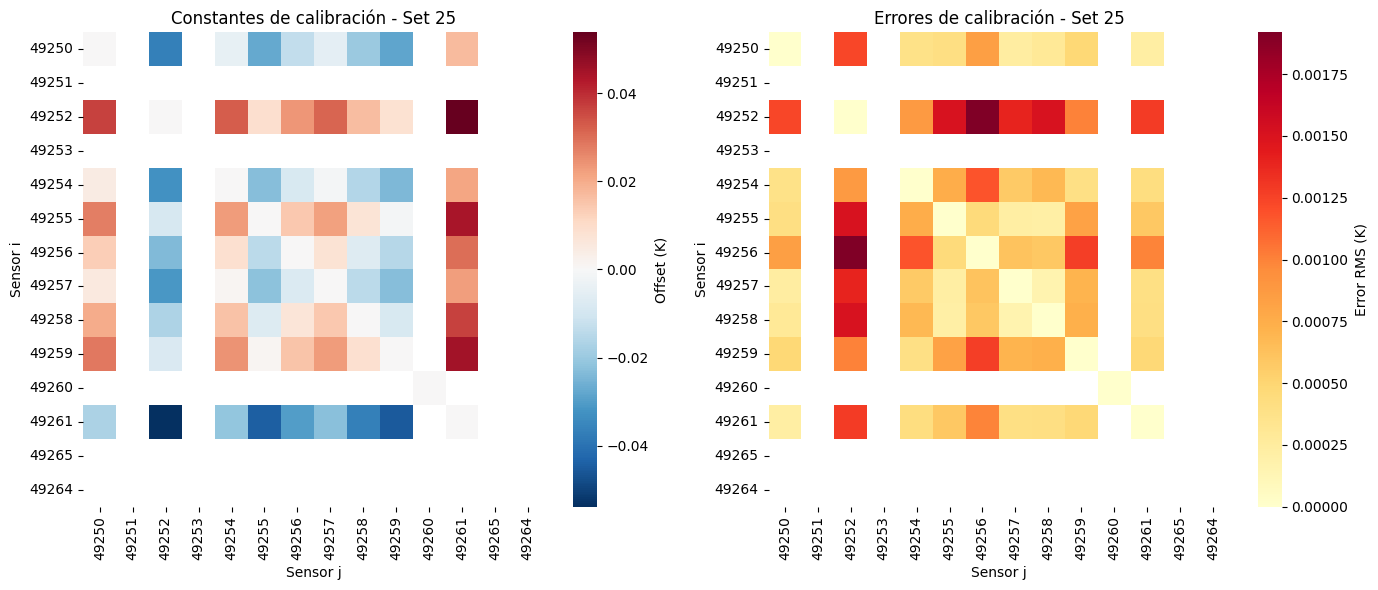


Estadísticas de offsets (valores absolutos):
  Mínimo: 0.0000 K
  Máximo: 0.0538 K
  Media: 0.0176 K
  Mediana: 0.0156 K


In [8]:
if set_to_view in calib_set.calibration_constants:
    constants = calib_set.calibration_constants[set_to_view]
    errors = calib_set.calibration_errors[set_to_view]
    
    # Crear figura con dos subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Heatmap de constantes
    sns.heatmap(constants, annot=False, fmt='.3f', cmap='RdBu_r', 
                center=0, cbar_kws={'label': 'Offset (K)'}, ax=axes[0])
    axes[0].set_title(f'Constantes de calibración - Set {set_to_view}')
    axes[0].set_xlabel('Sensor j')
    axes[0].set_ylabel('Sensor i')
    
    # Heatmap de errores
    sns.heatmap(errors, annot=False, fmt='.4f', cmap='YlOrRd', 
                cbar_kws={'label': 'Error RMS (K)'}, ax=axes[1])
    axes[1].set_title(f'Errores de calibración - Set {set_to_view}')
    axes[1].set_xlabel('Sensor j')
    axes[1].set_ylabel('Sensor i')
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas de la matriz
    print("\nEstadísticas de offsets (valores absolutos):")
    print(f"  Mínimo: {np.nanmin(np.abs(constants.values)):.4f} K")
    print(f"  Máximo: {np.nanmax(np.abs(constants.values)):.4f} K")
    print(f"  Media: {np.nanmean(np.abs(constants.values)):.4f} K")
    print(f"  Mediana: {np.nanmedian(np.abs(constants.values)):.4f} K")

### Comparar offsets entre sensores específicos

Visualiza los offsets de un sensor respecto a todos los demás.

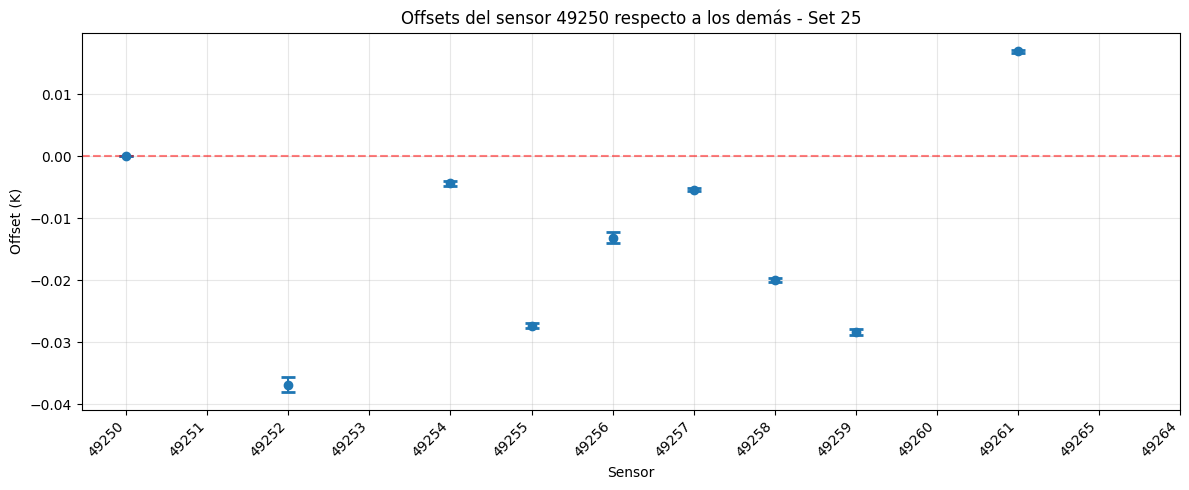

In [9]:
if set_to_view in calib_set.calibration_constants:
    constants = calib_set.calibration_constants[set_to_view]
    errors = calib_set.calibration_errors[set_to_view]
    
    # Seleccionar un sensor de referencia
    reference_sensor = constants.index[0]
    
    # Extraer offsets del sensor de referencia respecto a los demás
    offsets_vs_ref = constants.loc[reference_sensor, :]
    errors_vs_ref = errors.loc[reference_sensor, :]
    
    # Crear gráfico
    fig, ax = plt.subplots(figsize=(12, 5))
    x_pos = np.arange(len(offsets_vs_ref))
    
    ax.errorbar(x_pos, offsets_vs_ref, yerr=errors_vs_ref, 
                fmt='o', capsize=5, capthick=2, markersize=6)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(offsets_vs_ref.index, rotation=45, ha='right')
    ax.set_xlabel('Sensor')
    ax.set_ylabel('Offset (K)')
    ax.set_title(f'Offsets del sensor {reference_sensor} respecto a los demás - Set {set_to_view}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Guardar resultados

Exporta las matrices de constantes y errores a un archivo Excel.

## 5. Análisis de Repetibilidad: Histogramas de Sigmas por Ronda

Calcula la desviación estándar (sigma) del offset entre cada sensor y el sensor de referencia de su set, usando los 4 runs disponibles. Los histogramas muestran la distribución de estas sigmas con bins de 1 mK.

In [10]:
# Calcular histogramas de repetibilidad
repeatability_data = calib_set.calculate_repeatability_histograms(selected_sets=selected_sets)

# repeatability_data es una tupla (all_data, filtered_data)
# all_data    → todos los sensores (incluye descartados)
# filtered_data → solo sensores activos (excluye descartados)
data_source = repeatability_data[0]  # usamos el dict completo para el resumen

# Mostrar estadísticas resumidas por ronda
print("\n=== Estadísticas de Repetibilidad por Set ===")
for set_num in selected_sets:
    if set_num not in data_source:
        continue
    sigmas = data_source[set_num]
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(set_num, {})
    ronda = set_config.get('round', '?')
    referencias = [str(s) for s in set_config.get('reference', [])]
    descartados = [str(s) for s in set_config.get('discarded', [])]

    valid_sigmas = [s * 1000 for sid, s in sigmas.items()
                   if np.isfinite(s) and str(sid) not in referencias and str(sid) not in descartados]

    if valid_sigmas:
        print(f"\nSet {int(set_num)} (Ronda {ronda}):")
        print(f"  Sensores activos con sigma válida: {len(valid_sigmas)}")
        print(f"  Sigma media:   {np.mean(valid_sigmas):.3f} mK")
        print(f"  Sigma mediana: {np.median(valid_sigmas):.3f} mK")
        print(f"  Sigma mínima:  {np.min(valid_sigmas):.3f} mK")
        print(f"  Sigma máxima:  {np.max(valid_sigmas):.3f} mK")



=== Calculando histogramas de repetibilidad por ronda ===

Set 3:
  ℹ️  Referencias dinámicas: sensores raised ['48203', '48479']
  Sensor de referencia: 48479
  Sensores descartados: [48205, 48478]
  Total sensores procesados: 14
  Sigmas válidas (todos): 14
  Sigmas válidas (sin descartados): 10
  Sigma media (todos): 0.978 mK
  Sigma media (sin descartados): 0.634 mK
  Sigma máxima (todos): 4.027 mK

Set 4:
  ℹ️  Referencias dinámicas: sensores raised ['48484', '48491']
  Sensor de referencia: 48484
  Sensores descartados: [48485, 48490]
  Total sensores procesados: 14
  Sigmas válidas (todos): 14
  Sigmas válidas (sin descartados): 10
  Sigma media (todos): 0.920 mK
  Sigma media (sin descartados): 0.735 mK
  Sigma máxima (todos): 1.975 mK

Set 5:
  ℹ️  Referencias dinámicas: sensores raised ['48673', '48800']
  Sensor de referencia: 48673
  Sensores descartados: [48797]
  Total sensores procesados: 14
  Sigmas válidas (todos): 14
  Sigmas válidas (sin descartados): 11
  Sigma med

### Visualización de Histogramas

Histogramas con bins de 1 mK mostrando la distribución de sigmas de repetibilidad para cada set.

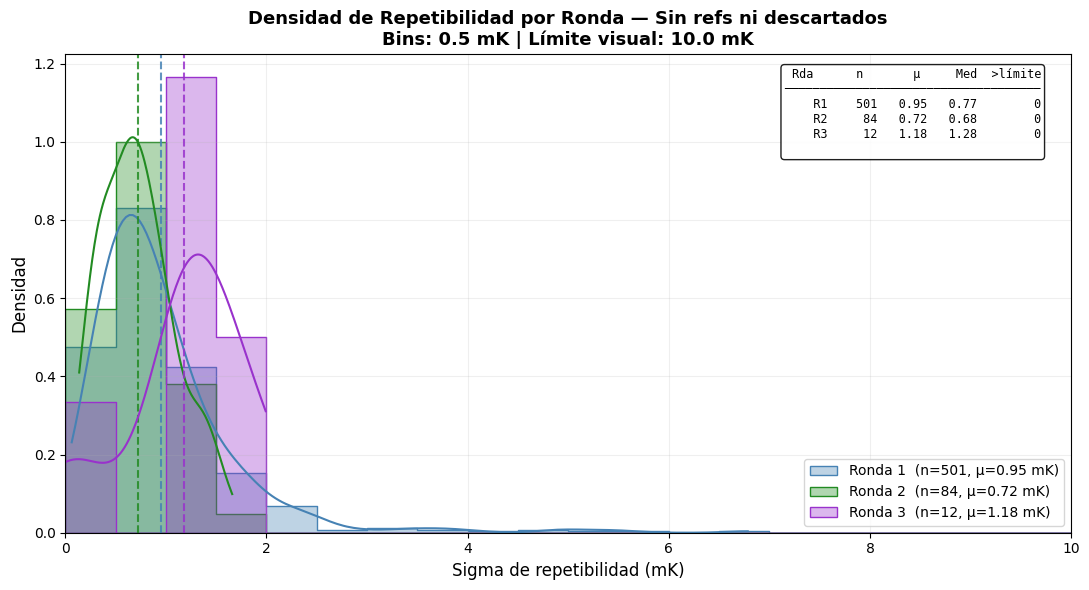

✅ Histograma por rondas generado.
  Ronda 1: n=501, media=0.955 mK, mediana=0.774 mK, max=6.785 mK, outliers (≥10.0 mK)=0
  Ronda 2: n=84, media=0.722 mK, mediana=0.680 mK, max=1.659 mK, outliers (≥10.0 mK)=0
  Ronda 3: n=12, media=1.183 mK, mediana=1.278 mK, max=1.992 mK, outliers (≥10.0 mK)=0


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- FUENTE DE DATOS ---
data_source = repeatability_data[0] if isinstance(repeatability_data, tuple) else repeatability_data

UMBRAL_MAX_MK = 10.0   # Límite visual (mK) — ajusta si quieres ver más rango
BIN_SIZE_MK   = 0.5    # Ancho de bin

# --- PALETA POR RONDA (dinámica, soporta más de 4) ---
_palette = {1: 'steelblue', 2: 'forestgreen', 3: 'darkorchid', 4: 'firebrick'}
_label_r = {1: 'Ronda 1', 2: 'Ronda 2', 3: 'Ronda 3', 4: 'Ronda 4'}

# --- 1. CLASIFICAR SIGMAS POR RONDA — sin refs ni descartados ---
rondas_data    = {}
outliers_ronda = {}

for set_num, sigmas_dict in data_source.items():
    s_key = int(float(set_num))
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(s_key, {})
    ronda = set_config.get('round', None)
    if not isinstance(ronda, int):
        continue  # Ignorar sets sin ronda entera (ej. 'Refs')
    excluidos = [str(s) for s in set_config.get('reference', []) + set_config.get('discarded', [])]
    if not isinstance(sigmas_dict, dict):
        continue
    for s_id, s_val in sigmas_dict.items():
        if not np.isfinite(s_val) or str(s_id) in excluidos:
            continue
        val_mK = s_val * 1000
        if val_mK < UMBRAL_MAX_MK:
            rondas_data.setdefault(ronda, []).append(val_mK)
        else:
            outliers_ronda[ronda] = outliers_ronda.get(ronda, 0) + 1

# --- 2. HISTOGRAMA SUPERPUESTO POR RONDA ---
if not rondas_data:
    print("❌ No se encontraron datos. Verifica que repeatability_data no esté vacío.")
else:
    fig, ax = plt.subplots(figsize=(11, 6))
    bins_arr = np.arange(0, UMBRAL_MAX_MK + BIN_SIZE_MK, BIN_SIZE_MK)

    for ronda in sorted(rondas_data.keys()):
        values = rondas_data[ronda]
        color  = _palette.get(ronda, 'gray')
        label  = _label_r.get(ronda, f'Ronda {ronda}')
        sns.histplot(values, bins=bins_arr, kde=True, stat="density",
                     label=f'{label}  (n={len(values)}, μ={np.mean(values):.2f} mK)',
                     color=color, element="step", alpha=0.35, ax=ax)
        ax.axvline(np.mean(values), color=color, linestyle='--', linewidth=1.5, alpha=0.85)

    # Cuadro de resumen
    hdr  = f"{'Rda':>3}  {'n':>5}  {'μ':>6}  {'Med':>6}  {'>límite':>7}\n" + "─" * 36 + "\n"
    body = "".join(
        f"  R{r}  {len(v):>5}  {np.mean(v):>5.2f}  {np.median(v):>5.2f}  {outliers_ronda.get(r, 0):>7}\n"
        for r, v in sorted(rondas_data.items())
    )
    ax.text(0.97, 0.97, hdr + body, transform=ax.transAxes, fontsize=8.5,
            va='top', ha='right', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.88))

    ax.set_title(f'Densidad de Repetibilidad por Ronda — Sin refs ni descartados\n'
                 f'Bins: {BIN_SIZE_MK} mK | Límite visual: {UMBRAL_MAX_MK} mK',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Sigma de repetibilidad (mK)', fontsize=12)
    ax.set_ylabel('Densidad', fontsize=12)
    ax.set_xlim(0, UMBRAL_MAX_MK)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    print("✅ Histograma por rondas generado.")
    for r in sorted(rondas_data.keys()):
        v = rondas_data[r]
        print(f"  Ronda {r}: n={len(v)}, media={np.mean(v):.3f} mK, "
              f"mediana={np.median(v):.3f} mK, max={np.max(v):.3f} mK, "
              f"outliers (≥{UMBRAL_MAX_MK} mK)={outliers_ronda.get(r, 0)}")


In [12]:
import pandas as pd

# --- CORRECCIÓN DE LA TUPLA ---
if isinstance(repeatability_data, tuple):
    data_to_process = repeatability_data[0]
else:
    data_to_process = repeatability_data

# --- CONTABILIZACIÓN ---
stats_list = []
UMBRAL_MAX_MK = 50.0

for set_num, sigmas_dict in data_to_process.items():
    s_key = int(float(set_num))
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(s_key, {})
    
    # Referencias y Descartados
    refs = [str(s) for s in set_config.get('reference', [])]
    discs = [str(s) for s in set_config.get('discarded', [])]
    excluidos = refs + discs
    
    # Contadores
    count_valid = 0
    count_outliers = 0
    
    if isinstance(sigmas_dict, dict):
        for s_id, s_val in sigmas_dict.items():
            if np.isfinite(s_val):
                val_mK = s_val * 1000
                if str(s_id) not in excluidos:
                    if val_mK < UMBRAL_MAX_MK:
                        count_valid += 1
                    else:
                        count_outliers += 1
    
    stats_list.append({
        'Set': s_key,
        'Sensores Graficados': count_valid,
        'Referencias (Excluidas)': len(refs),
        'Descartados (Excluidos)': len(discs),
        'Outliers (>50mK)': count_outliers
    })

# Mostrar como DataFrame para que se vea ordenado
df_stats = pd.DataFrame(stats_list).sort_values('Set')
print("=== DESGLOSE DE SENSORES POR SET EN EL HISTOGRAMA ===")
print(df_stats.to_string(index=False))
print(f"\nTOTAL SENSORES EN EL PLOT: {df_stats['Sensores Graficados'].sum()}")

=== DESGLOSE DE SENSORES POR SET EN EL HISTOGRAMA ===
 Set  Sensores Graficados  Referencias (Excluidas)  Descartados (Excluidos)  Outliers (>50mK)
   3                   10                        2                        2                 0
   4                   10                        2                        2                 0
   5                   11                        2                        1                 0
   6                   10                        2                        2                 0
   7                    9                        2                        3                 0
   8                   10                        2                        2                 0
   9                   12                        2                        0                 0
  10                   12                        2                        0                 0
  11                   12                        2                        0                 0
  13  

In [13]:
# --- IDENTIFICACIÓN DE SENSORES CON SIGMA > 50 mK ---

# Manejo de la tupla si es necesario
if isinstance(repeatability_data, tuple):
    data_to_process = repeatability_data[0]
else:
    data_to_process = repeatability_data

outliers_report = []
UMBRAL_DETECCION = 50.0 # mK

for set_num, sigmas_dict in data_to_process.items():
    s_key = int(float(set_num))
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(s_key, {})
    
    # Listas del config
    discarded_en_config = [str(s) for s in set_config.get('discarded', [])]
    referencia = [str(s) for s in set_config.get('reference', [])]

    if isinstance(sigmas_dict, dict):
        for s_id, val in sigmas_dict.items():
            val_mK = val * 1000
            
            # Si la sigma es mayor que el umbral (o es infinita)
            if val_mK > UMBRAL_DETECCION or not np.isfinite(val):
                
                # Verificamos su estado
                ya_descartado = str(s_id) in discarded_en_config
                es_referencia = str(s_id) in referencia
                
                outliers_report.append({
                    'Set': s_key,
                    'Sensor ID': s_id,
                    'Sigma (mK)': f"{val_mK:.2f}" if np.isfinite(val) else "INFINITA",
                    'Estado en Config': 'DESCARTADO' if ya_descartado else ('REFERENCIA' if es_referencia else 'ACTIVO (Outlier Nuevo)')
                })

# Crear tabla de resultados
import pandas as pd
df_outliers = pd.DataFrame(outliers_report)

if not df_outliers.empty:
    print(f"=== SENSORES CON SIGMA > {UMBRAL_DETECCION} mK O INVÁLIDOS ===")
    # Ordenar por Sigma de mayor a menor para ver los peores primero
    # (Nota: los infinitos saldrán al final o darán error al ordenar, así que filtramos antes)
    print(df_outliers.sort_values('Set').to_string(index=False))
    
    # Resumen
    nuevos = len(df_outliers[df_outliers['Estado en Config'] == 'ACTIVO (Outlier Nuevo)'])
    print(f"\nAlerta: Se han encontrado {nuevos} sensores con errores altos que NO están en tu lista de descartados.")
else:
    print(f"✅ ¡Genial! No hay ningún sensor con sigma mayor a {UMBRAL_DETECCION} mK fuera de los descartados.")

=== SENSORES CON SIGMA > 50.0 mK O INVÁLIDOS ===
 Set Sensor ID Sigma (mK) Estado en Config
  30     49316   INFINITA       DESCARTADO

Alerta: Se han encontrado 0 sensores con errores altos que NO están en tu lista de descartados.


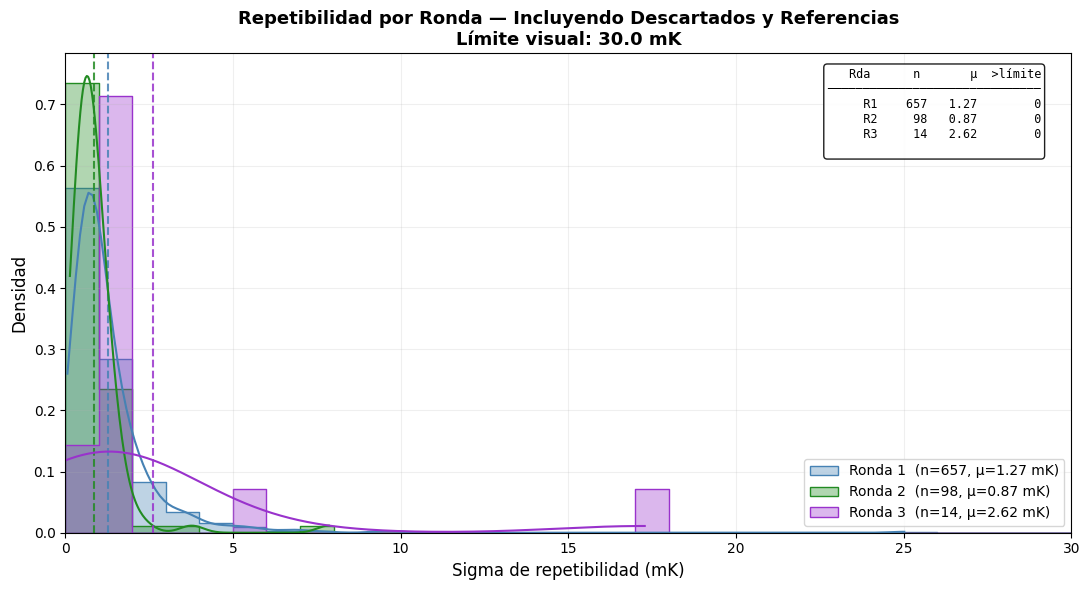

✅ Histograma generado. En rango: 769 | Fuera de rango (>30.0 mK): 0


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- FUENTE DE DATOS ---
data_source = repeatability_data[0] if isinstance(repeatability_data, tuple) else repeatability_data

UMBRAL_PLOT = 30.0   # Límite visual (mK)
BIN_SIZE_MK = 1.0

_palette = {1: 'steelblue', 2: 'forestgreen', 3: 'darkorchid', 4: 'firebrick'}
_label_r = {1: 'Ronda 1', 2: 'Ronda 2', 3: 'Ronda 3', 4: 'Ronda 4'}

# --- 1. CLASIFICAR POR RONDA — incluye TODO (refs + descartados) ---
rondas_data    = {}
outliers_ronda = {}

for set_num, sigmas_dict in data_source.items():
    s_key = int(float(set_num))
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(s_key, {})
    ronda = set_config.get('round', None)
    if not isinstance(ronda, int):
        continue
    if not isinstance(sigmas_dict, dict):
        continue
    for s_id, s_val in sigmas_dict.items():
        if not np.isfinite(s_val):
            continue
        val_mK = s_val * 1000
        if val_mK <= UMBRAL_PLOT:
            rondas_data.setdefault(ronda, []).append(val_mK)
        else:
            outliers_ronda[ronda] = outliers_ronda.get(ronda, 0) + 1

# --- 2. PLOT ---
if not rondas_data:
    print("❌ No hay datos suficientes.")
else:
    fig, ax = plt.subplots(figsize=(11, 6))
    bins_arr = np.arange(0, UMBRAL_PLOT + BIN_SIZE_MK, BIN_SIZE_MK)

    for ronda in sorted(rondas_data.keys()):
        values = rondas_data[ronda]
        color  = _palette.get(ronda, 'gray')
        label  = _label_r.get(ronda, f'Ronda {ronda}')
        sns.histplot(values, bins=bins_arr, kde=True, stat="density",
                     label=f'{label}  (n={len(values)}, μ={np.mean(values):.2f} mK)',
                     color=color, element="step", alpha=0.35, ax=ax)
        ax.axvline(np.mean(values), color=color, linestyle='--', linewidth=1.5, alpha=0.85)

    hdr  = f"{'Rda':>3}  {'n':>5}  {'μ':>6}  {'>límite':>7}\n" + "─" * 30 + "\n"
    body = "".join(
        f"  R{r}  {len(v):>5}  {np.mean(v):>5.2f}  {outliers_ronda.get(r, 0):>7}\n"
        for r, v in sorted(rondas_data.items())
    )
    ax.text(0.97, 0.97, hdr + body, transform=ax.transAxes, fontsize=8.5,
            va='top', ha='right', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.88))

    ax.set_title(f'Repetibilidad por Ronda — Incluyendo Descartados y Referencias\n'
                 f'Límite visual: {UMBRAL_PLOT} mK',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Sigma de repetibilidad (mK)', fontsize=12)
    ax.set_ylabel('Densidad', fontsize=12)
    ax.set_xlim(0, UMBRAL_PLOT)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    total_in  = sum(len(v) for v in rondas_data.values())
    total_out = sum(outliers_ronda.values())
    print(f"✅ Histograma generado. En rango: {total_in} | Fuera de rango (>{UMBRAL_PLOT} mK): {total_out}")


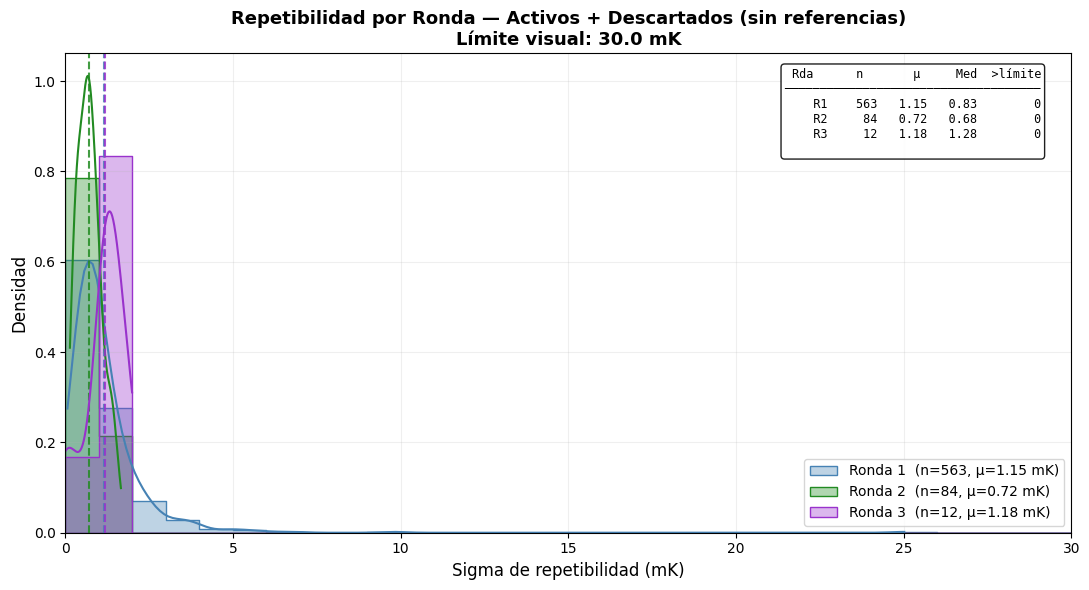

✅ Histograma generado. En rango: 659 | Fuera de rango (>30.0 mK): 0


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- FUENTE DE DATOS ---
data_source = repeatability_data[0] if isinstance(repeatability_data, tuple) else repeatability_data

UMBRAL_PLOT = 30.0
BIN_SIZE_MK = 1.0

_palette = {1: 'steelblue', 2: 'forestgreen', 3: 'darkorchid', 4: 'firebrick'}
_label_r = {1: 'Ronda 1', 2: 'Ronda 2', 3: 'Ronda 3', 4: 'Ronda 4'}

# --- 1. CLASIFICAR POR RONDA — descartados SÍ, referencias NO ---
rondas_data    = {}
outliers_ronda = {}

for set_num, sigmas_dict in data_source.items():
    s_key = int(float(set_num))
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(s_key, {})
    ronda = set_config.get('round', None)
    if not isinstance(ronda, int):
        continue
    referencias = [str(s) for s in set_config.get('reference', [])]
    if not isinstance(sigmas_dict, dict):
        continue
    for s_id, s_val in sigmas_dict.items():
        if not np.isfinite(s_val) or str(s_id) in referencias:
            continue
        val_mK = s_val * 1000
        if val_mK <= UMBRAL_PLOT:
            rondas_data.setdefault(ronda, []).append(val_mK)
        else:
            outliers_ronda[ronda] = outliers_ronda.get(ronda, 0) + 1

# --- 2. PLOT ---
if not rondas_data:
    print("❌ No se encontraron datos válidos.")
else:
    fig, ax = plt.subplots(figsize=(11, 6))
    bins_arr = np.arange(0, UMBRAL_PLOT + BIN_SIZE_MK, BIN_SIZE_MK)

    for ronda in sorted(rondas_data.keys()):
        values = rondas_data[ronda]
        color  = _palette.get(ronda, 'gray')
        label  = _label_r.get(ronda, f'Ronda {ronda}')
        sns.histplot(values, bins=bins_arr, kde=True, stat="density",
                     label=f'{label}  (n={len(values)}, μ={np.mean(values):.2f} mK)',
                     color=color, element="step", alpha=0.35, ax=ax)
        ax.axvline(np.mean(values), color=color, linestyle='--', linewidth=1.5, alpha=0.85)

    hdr  = f"{'Rda':>3}  {'n':>5}  {'μ':>6}  {'Med':>6}  {'>límite':>7}\n" + "─" * 36 + "\n"
    body = "".join(
        f"  R{r}  {len(v):>5}  {np.mean(v):>5.2f}  {np.median(v):>5.2f}  {outliers_ronda.get(r, 0):>7}\n"
        for r, v in sorted(rondas_data.items())
    )
    ax.text(0.97, 0.97, hdr + body, transform=ax.transAxes, fontsize=8.5,
            va='top', ha='right', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.88))

    ax.set_title(f'Repetibilidad por Ronda — Activos + Descartados (sin referencias)\n'
                 f'Límite visual: {UMBRAL_PLOT} mK',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Sigma de repetibilidad (mK)', fontsize=12)
    ax.set_ylabel('Densidad', fontsize=12)
    ax.set_xlim(0, UMBRAL_PLOT)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    total_in  = sum(len(v) for v in rondas_data.values())
    total_out = sum(outliers_ronda.values())
    print(f"✅ Histograma generado. En rango: {total_in} | Fuera de rango (>{UMBRAL_PLOT} mK): {total_out}")


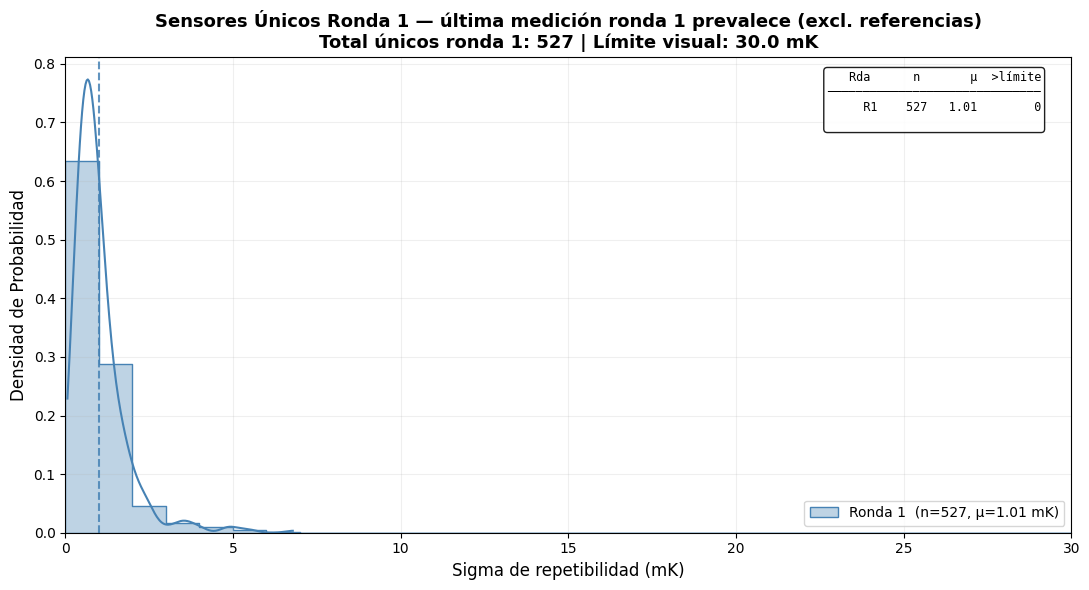

✅ 527 sensores únicos ronda 1.
   En rango: 527 | Fuera de rango (>30.0 mK): 0
   Nota: se usa la medición del set de ronda 1 con número más alto por sensor.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- FUENTE DE DATOS ---
data_source = repeatability_data[0] if isinstance(repeatability_data, tuple) else repeatability_data

UMBRAL_PLOT = 30.0
BIN_SIZE_MK = 1.0

_palette = {1: 'steelblue', 2: 'forestgreen', 3: 'darkorchid', 4: 'firebrick'}
_label_r = {1: 'Ronda 1', 2: 'Ronda 2', 3: 'Ronda 3', 4: 'Ronda 4'}

# --- 1. SENSORES ÚNICOS RONDA 1 — última medición ronda 1 prevalece, sin refs ---
# Solo se procesan sets de ronda 1. Si un sensor fue re-medido en ronda 2,
# se usa su último valor de ronda 1 (el set de ronda 1 con número mayor).
unique_map = {}
sorted_set_names = sorted(data_source.keys(), key=lambda x: int(float(x)))

for set_num in sorted_set_names:
    s_key = int(float(set_num))
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(s_key, {})
    ronda = set_config.get('round', None)
    if not isinstance(ronda, int):
        continue
    if ronda != 1:          # solo ronda 1 → última medición ronda 1 prevalece
        continue
    referencias = [str(s) for s in set_config.get('reference', [])]
    sigmas_dict = data_source[set_num]
    if not isinstance(sigmas_dict, dict):
        continue
    for s_id, s_val in sigmas_dict.items():
        if not np.isfinite(s_val) or str(s_id) in referencias:
            continue
        unique_map[str(s_id)] = (s_val * 1000, ronda)

# --- 2. AGRUPAR POR RONDA ---
rondas_data    = {}
outliers_ronda = {}

for sid, (val_mK, ronda) in unique_map.items():
    if val_mK <= UMBRAL_PLOT:
        rondas_data.setdefault(ronda, []).append(val_mK)
    else:
        outliers_ronda[ronda] = outliers_ronda.get(ronda, 0) + 1

# --- 3. PLOT ---
if not rondas_data:
    print("❌ No se encontraron datos para los sensores únicos.")
else:
    fig, ax = plt.subplots(figsize=(11, 6))
    bins_arr = np.arange(0, UMBRAL_PLOT + BIN_SIZE_MK, BIN_SIZE_MK)

    for ronda in sorted(rondas_data.keys()):
        values = rondas_data[ronda]
        color  = _palette.get(ronda, 'gray')
        label  = _label_r.get(ronda, f'Ronda {ronda}')
        sns.histplot(values, bins=bins_arr, kde=True, stat="density",
                     label=f'{label}  (n={len(values)}, μ={np.mean(values):.2f} mK)',
                     color=color, element="step", alpha=0.35, ax=ax)
        ax.axvline(np.mean(values), color=color, linestyle='--', linewidth=1.5, alpha=0.85)

    total_unique = len(unique_map)
    hdr  = f"{'Rda':>3}  {'n':>5}  {'μ':>6}  {'>límite':>7}\n" + "─" * 30 + "\n"
    body = "".join(
        f"  R{r}  {len(v):>5}  {np.mean(v):>5.2f}  {outliers_ronda.get(r, 0):>7}\n"
        for r, v in sorted(rondas_data.items())
    )
    ax.text(0.97, 0.97, hdr + body, transform=ax.transAxes, fontsize=8.5,
            va='top', ha='right', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.88))

    ax.set_title(f'Sensores Únicos Ronda 1 — última medición ronda 1 prevalece (excl. referencias)\n'
                 f'Total únicos ronda 1: {total_unique} | Límite visual: {UMBRAL_PLOT} mK',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Sigma de repetibilidad (mK)', fontsize=12)
    ax.set_ylabel('Densidad de Probabilidad', fontsize=12)
    ax.set_xlim(0, UMBRAL_PLOT)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    total_in  = sum(len(v) for v in rondas_data.values())
    total_out = sum(outliers_ronda.values())
    print(f"✅ {total_unique} sensores únicos ronda 1.")
    print(f"   En rango: {total_in} | Fuera de rango (>{UMBRAL_PLOT} mK): {total_out}")
    print("   Nota: se usa la medición del set de ronda 1 con número más alto por sensor.")


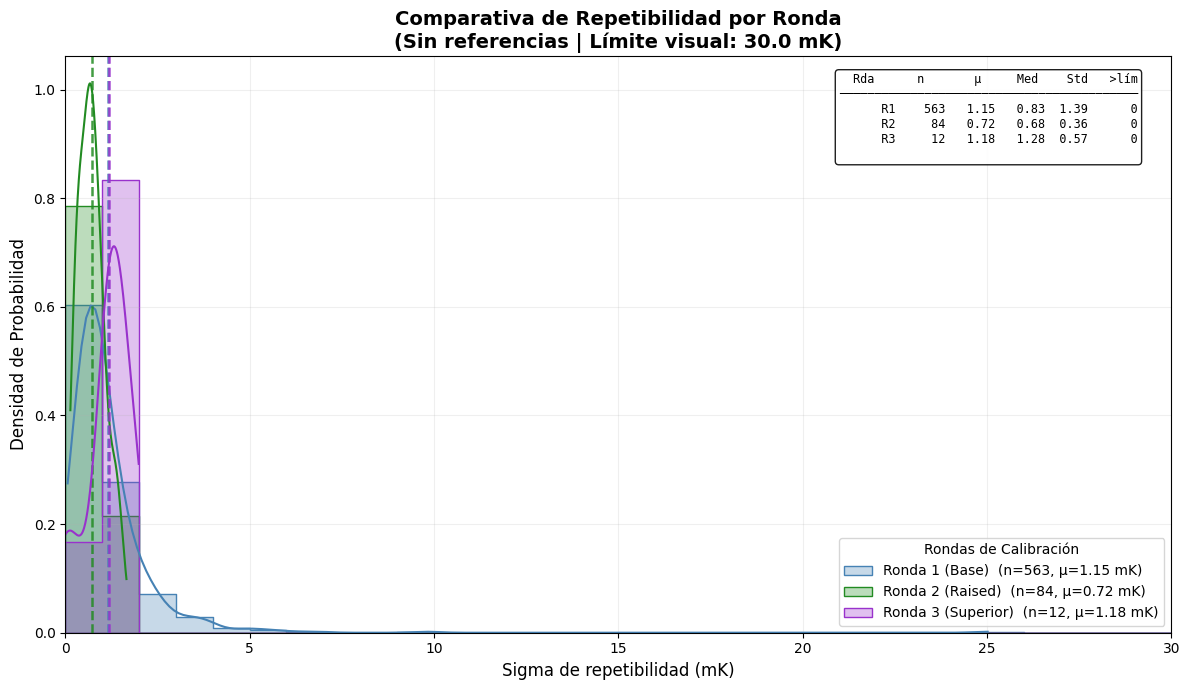


=== ESTADÍSTICAS POR RONDA ===
  Ronda 1: n=563, media=1.150 mK, mediana=0.834 mK, std=1.393 mK, fuera rango=0
  Ronda 2: n=84, media=0.722 mK, mediana=0.680 mK, std=0.362 mK, fuera rango=0
  Ronda 3: n=12, media=1.183 mK, mediana=1.278 mK, std=0.566 mK, fuera rango=0


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- FUENTE DE DATOS ---
data_source = repeatability_data[0] if isinstance(repeatability_data, tuple) else repeatability_data

UMBRAL_PLOT = 30.0   # Límite visual (mK)
BIN_SIZE_MK = 1.0

_palette = {1: 'steelblue', 2: 'forestgreen', 3: 'darkorchid', 4: 'firebrick'}
_label_r = {1: 'Ronda 1 (Base)', 2: 'Ronda 2 (Raised)', 3: 'Ronda 3 (Superior)', 4: 'Ronda 4'}

# --- 1. CLASIFICAR SIGMAS POR RONDA (leyendo ronda del config, sin refs) ---
rondas_data    = {}
outliers_ronda = {}

for set_num, sigmas_dict in data_source.items():
    s_key = int(float(set_num))
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(s_key, {})
    ronda = set_config.get('round', None)
    if not isinstance(ronda, int):
        continue  # Ignora sets sin ronda entera (ej. 'Refs')
    referencias = [str(s) for s in set_config.get('reference', [])]
    if not isinstance(sigmas_dict, dict):
        continue
    for s_id, s_val in sigmas_dict.items():
        if not np.isfinite(s_val) or str(s_id) in referencias:
            continue
        val_mK = s_val * 1000
        if val_mK < UMBRAL_PLOT:
            rondas_data.setdefault(ronda, []).append(val_mK)
        else:
            outliers_ronda[ronda] = outliers_ronda.get(ronda, 0) + 1

# --- 2. HISTOGRAMA SUPERPUESTO ---
if not rondas_data:
    print("❌ No se encontraron datos.")
else:
    fig, ax = plt.subplots(figsize=(12, 7))
    bins_arr = np.arange(0, UMBRAL_PLOT + BIN_SIZE_MK, BIN_SIZE_MK)

    for ronda in sorted(rondas_data.keys()):
        values = rondas_data[ronda]
        color  = _palette.get(ronda, 'gray')
        label  = _label_r.get(ronda, f'Ronda {ronda}')
        sns.histplot(values, bins=bins_arr, kde=True, stat="density",
                     label=f'{label}  (n={len(values)}, μ={np.mean(values):.2f} mK)',
                     color=color, element="step", alpha=0.3, ax=ax)
        ax.axvline(np.mean(values), color=color, linestyle='--', linewidth=1.8, alpha=0.85)

    # Cuadro de resumen
    hdr  = f"{'Rda':>3}  {'n':>5}  {'μ':>6}  {'Med':>6}  {'Std':>5}  {'>lím':>5}\n" + "─" * 42 + "\n"
    body = "".join(
        f"  R{r}  {len(v):>5}  {np.mean(v):>5.2f}  {np.median(v):>5.2f}  {np.std(v):>4.2f}  {outliers_ronda.get(r, 0):>5}\n"
        for r, v in sorted(rondas_data.items())
    )
    ax.text(0.97, 0.97, hdr + body, transform=ax.transAxes, fontsize=8.5,
            va='top', ha='right', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.88))

    ax.set_title(f'Comparativa de Repetibilidad por Ronda\n'
                 f'(Sin referencias | Límite visual: {UMBRAL_PLOT} mK)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Sigma de repetibilidad (mK)', fontsize=12)
    ax.set_ylabel('Densidad de Probabilidad', fontsize=12)
    ax.set_xlim(0, UMBRAL_PLOT)
    ax.legend(title="Rondas de Calibración", fontsize=10)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    # Resumen en consola
    print("\n=== ESTADÍSTICAS POR RONDA ===")
    for ronda in sorted(rondas_data.keys()):
        v = rondas_data[ronda]
        print(f"  Ronda {ronda}: n={len(v)}, media={np.mean(v):.3f} mK, "
              f"mediana={np.median(v):.3f} mK, std={np.std(v):.3f} mK, "
              f"fuera rango={outliers_ronda.get(ronda, 0)}")


## 🔍 Debug: Scatter de Sigmas por Sensor (estilo SET_BUENO)

Muestra la sigma de repetibilidad por sensor para cada set, agrupados por set.
Permite identificar sensores o sets con sigmas anómalas (ej. Set 57 / Ronda 3).


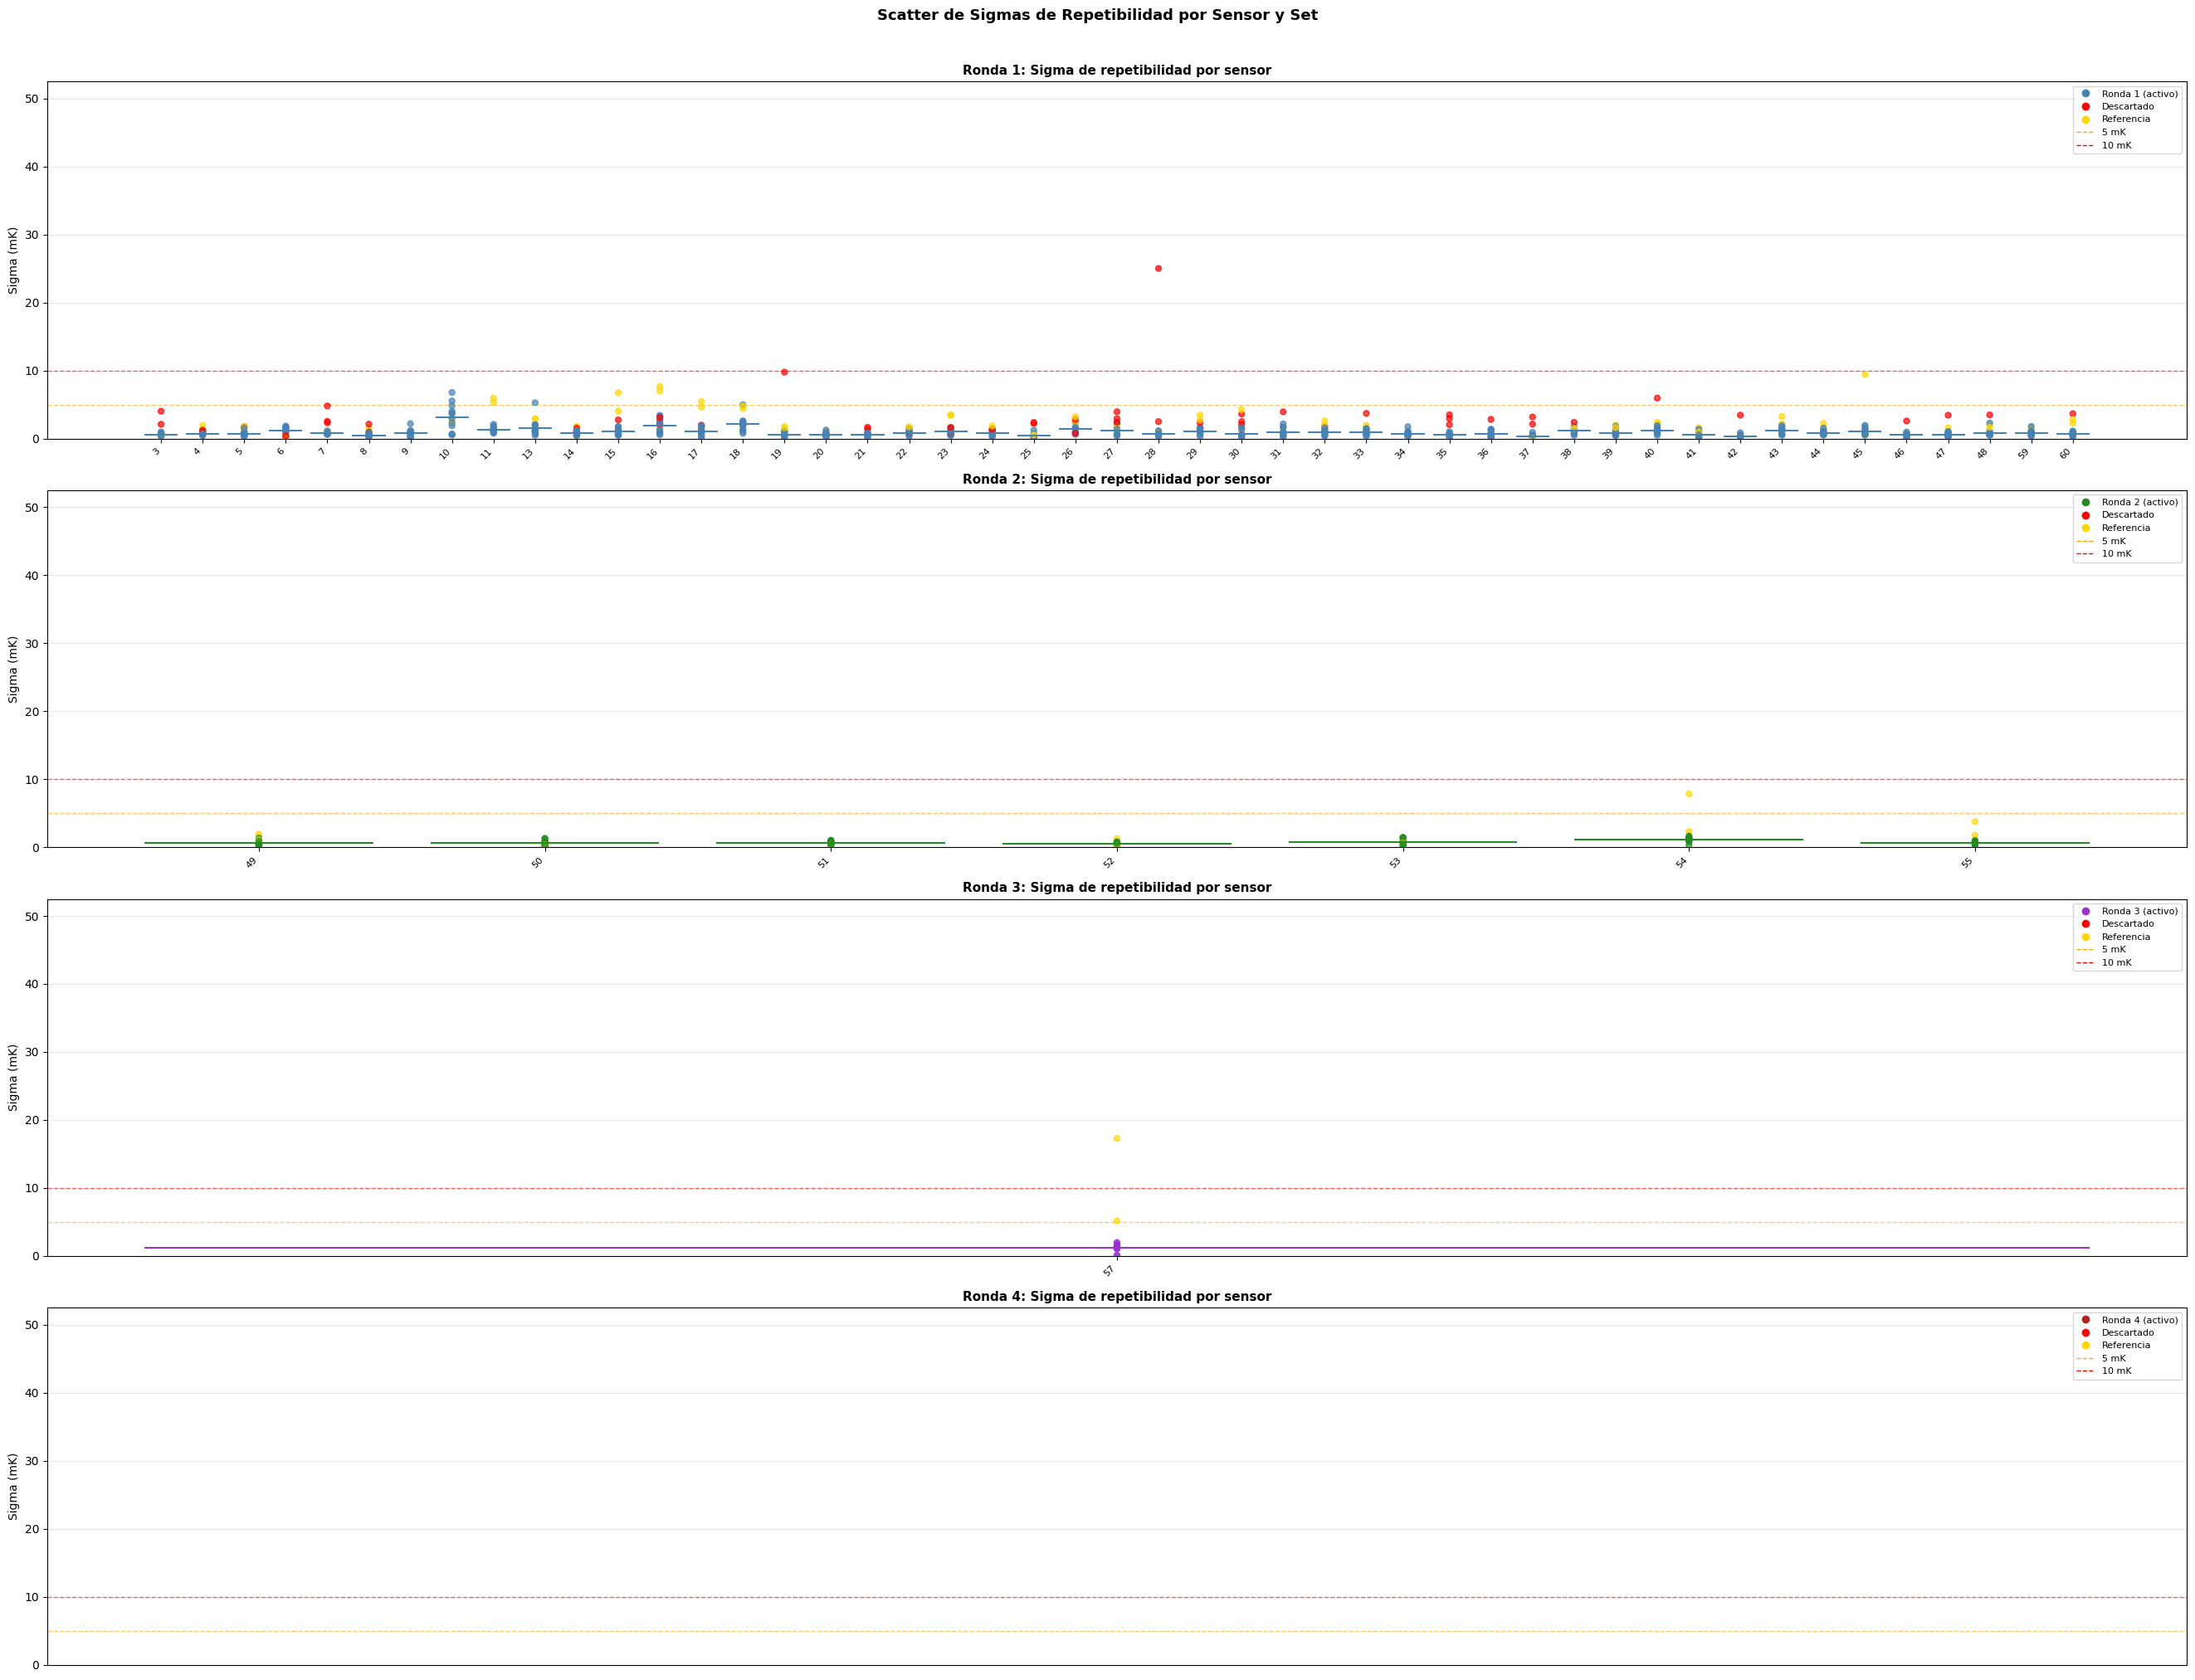

✅ Scatter de sigmas generado. Líneas horizontales = media del set (sólo sensores activos).
   Puntos rojos = descartados | Puntos dorados = referencias | Líneas discontinuas = umbral 5/10 mK


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
data_source = repeatability_data[0] if isinstance(repeatability_data, tuple) else repeatability_data
UMBRAL_PLOT_SCATTER = 50.0  # mK - umbral visual para el scatter

# Colores por ronda
color_map = {1: 'steelblue', 2: 'forestgreen', 3: 'darkorchid', 4: 'firebrick'}

# Agrupar sets por ronda (solo rondas enteras; ignorar 'Refs' y similares)
sets_por_ronda = {}
for s in selected_sets:
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(s, {})
    ronda = set_config.get('round', 1)
    if not isinstance(ronda, int):
        continue  # ignorar 'Refs', None, etc.
    sets_por_ronda.setdefault(ronda, []).append(s)

if not sets_por_ronda:
    print("⚠️  No hay sets con ronda entera para graficar.")
else:
    fig, axes = plt.subplots(len(sets_por_ronda), 1,
                             figsize=(max(16, len(selected_sets) * 0.45), 5 * len(sets_por_ronda)),
                             squeeze=False)

    for ax_idx, (ronda, sets_ronda) in enumerate(sorted(sets_por_ronda.items())):
        ax = axes[ax_idx][0]
        xtick_labels = []
        xtick_positions = []
        x_pos = 0

        for set_num in sorted(sets_ronda):
            s_key = set_num
            if s_key not in data_source:
                s_key = float(set_num) if float(set_num) in data_source else set_num
            if s_key not in data_source:
                continue

            sigmas_dict = data_source[s_key]
            set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(set_num, {})
            referencias = [str(s) for s in set_config.get('reference', [])]
            descartados = [str(s) for s in set_config.get('discarded', [])]

            set_xs = []
            set_ys = []
            set_colors_pt = []

            for s_id, s_val in sigmas_dict.items():
                if not np.isfinite(s_val):
                    continue
                val_mK = s_val * 1000
                set_xs.append(x_pos)
                set_ys.append(min(val_mK, UMBRAL_PLOT_SCATTER))
                if str(s_id) in referencias:
                    set_colors_pt.append('gold')
                elif str(s_id) in descartados:
                    set_colors_pt.append('red')
                else:
                    set_colors_pt.append(color_map.get(ronda, 'gray'))

            if set_xs:
                ax.scatter(set_xs, set_ys, c=set_colors_pt, s=25, alpha=0.7, zorder=3)
                active_ys = [y for y, c in zip(set_ys, set_colors_pt)
                             if c not in ('gold', 'red')]
                if active_ys:
                    mean_val = np.mean(active_ys)
                    ax.hlines(mean_val, x_pos - 0.4, x_pos + 0.4,
                              colors=color_map.get(ronda, 'gray'), linewidths=1.5, zorder=4)

            xtick_labels.append(str(int(set_num)))
            xtick_positions.append(x_pos)
            x_pos += 1

        ax.set_xticks(xtick_positions)
        ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Sigma (mK)', fontsize=10)
        ax.set_ylim(0, UMBRAL_PLOT_SCATTER * 1.05)
        ax.axhline(5, color='orange', linestyle='--', linewidth=1, alpha=0.6)
        ax.axhline(10, color='red', linestyle='--', linewidth=1, alpha=0.6)
        ax.set_title(f'Ronda {ronda}: Sigma de repetibilidad por sensor', fontsize=11, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.3)

        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map.get(ronda, 'gray'),
                   markersize=8, label=f'Ronda {ronda} (activo)'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Descartado'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='gold', markersize=8, label='Referencia'),
            Line2D([0], [0], color='orange', linestyle='--', linewidth=1, label='5 mK'),
            Line2D([0], [0], color='red', linestyle='--', linewidth=1, label='10 mK'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.suptitle('Scatter de Sigmas de Repetibilidad por Sensor y Set', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print("✅ Scatter de sigmas generado. Líneas horizontales = media del set (sólo sensores activos).")
    print("   Puntos rojos = descartados | Puntos dorados = referencias | Líneas discontinuas = umbral 5/10 mK")


### 🔍 Debug: Offsets por run para un set específico

Muestra los offsets de cada run respecto al sensor de referencia, para cada sensor.
Útil para ver qué runs son outliers (causa de sigma alta, ej. en Set 57 con 10 runs de varias fechas).


Set 57 | 7 runs | Referencia: 48177 | Descartados: []


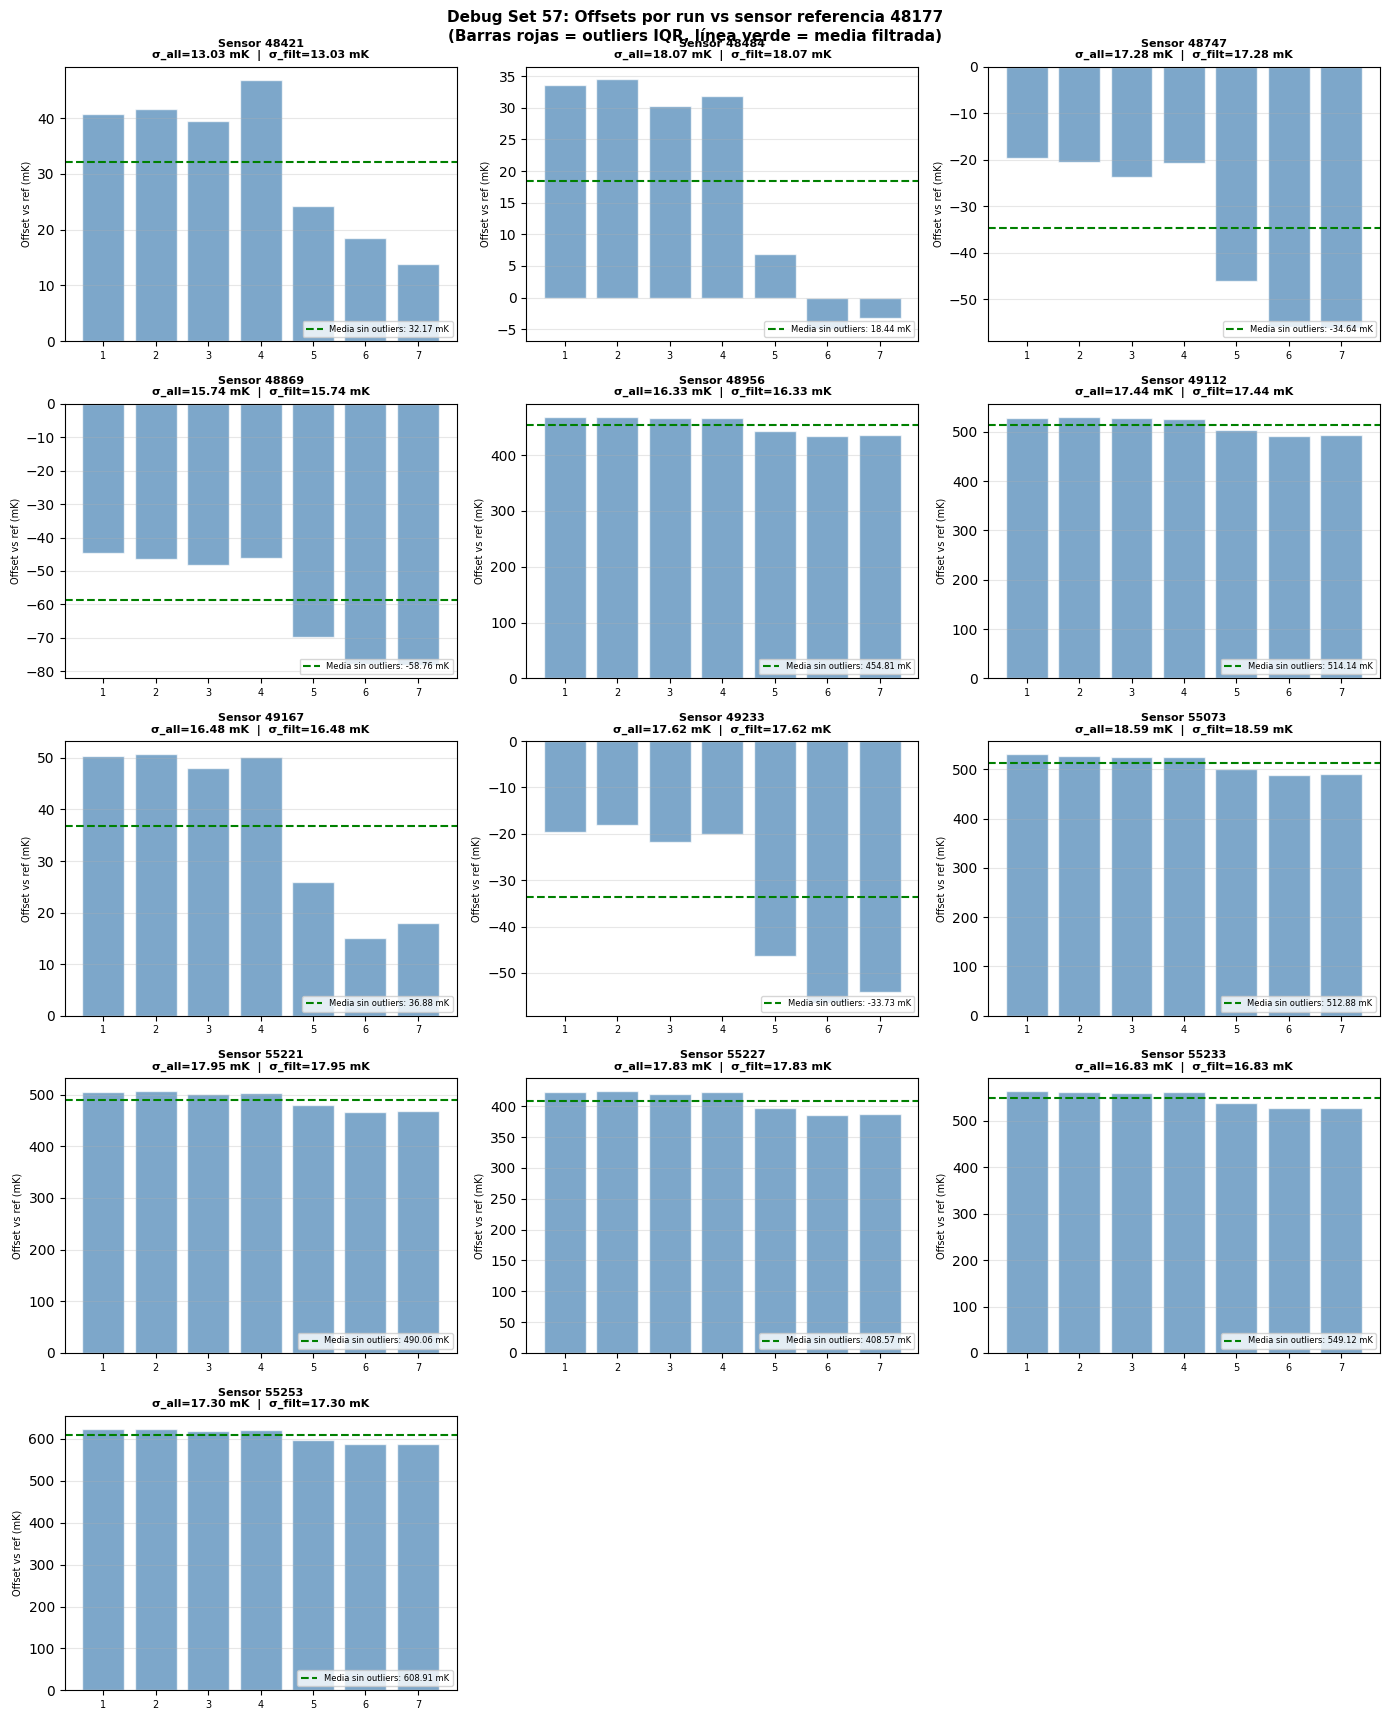

✅ 13 sensores mostrados. Barras rojas = runs filtrados por IQR en set.py.


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN: Cambia este número para depurar cualquier set ---
DEBUG_SET = 57  # <- cambia aquí para inspeccionar otro set

if DEBUG_SET not in calib_set.runs_by_set:
    print(f"❌ Set {DEBUG_SET} no tiene runs cargados. Añádelo a selected_sets y vuelve a ejecutar group_runs().")
else:
    runs = calib_set.runs_by_set[DEBUG_SET]
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(DEBUG_SET, {})
    reference_sensors = set_config.get('reference', [])
    discarded_sensors = [str(s) for s in set_config.get('discarded', [])]
    ref_sensor = str(reference_sensors[0]) if reference_sensors else None

    print(f"Set {DEBUG_SET} | {len(runs)} runs | Referencia: {ref_sensor} | Descartados: {discarded_sensors}")

    # Recolectar offset vs referencia por run
    offsets_by_sensor = {}  # {sensor_id: [(run_label, offset_mean), ...]}

    for filename, run in sorted(runs.items()):
        try:
            offsets, _ = run.calculate_offsets()
            if ref_sensor not in offsets.columns:
                print(f"  ⚠️  {filename}: sensor referencia {ref_sensor} no encontrado")
                continue
            offsets_to_ref = offsets[ref_sensor]
            for sensor_id, val in offsets_to_ref.items():
                if np.isfinite(val):
                    offsets_by_sensor.setdefault(str(sensor_id), []).append((filename[-30:], val * 1000))
        except Exception as e:
            print(f"  ✗ Error en {filename}: {e}")

    # --- PLOT: un subplot por sensor ---
    sensors_to_plot = [s for s in offsets_by_sensor if s not in discarded_sensors and s != ref_sensor]
    n_sensors = len(sensors_to_plot)

    if n_sensors == 0:
        print("No hay sensores activos para mostrar.")
    else:
        ncols = 3
        nrows = (n_sensors + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), squeeze=False)
        axes_flat = axes.flatten()

        for i, sensor_id in enumerate(sorted(sensors_to_plot)):
            ax = axes_flat[i]
            runs_data = offsets_by_sensor[sensor_id]
            labels = [r[0] for r in runs_data]
            values = np.array([r[1] for r in runs_data])

            # IQR bounds (igual que en set.py)
            if len(values) >= 4:
                q1, q3 = np.percentile(values, 25), np.percentile(values, 75)
                iqr = q3 - q1
                lb, ub = q1 - 3 * iqr, q3 + 3 * iqr
                is_outlier = (values < lb) | (values > ub)
            else:
                lb, ub = -np.inf, np.inf
                is_outlier = np.zeros(len(values), dtype=bool)

            colors = ['red' if o else 'steelblue' for o in is_outlier]
            ax.bar(range(len(values)), values, color=colors, alpha=0.7, edgecolor='white')
            ax.axhline(np.mean(values[~is_outlier]), color='green', linestyle='--',
                       linewidth=1.5, label=f'Media sin outliers: {np.mean(values[~is_outlier]):.2f} mK')
            if any(is_outlier):
                ax.axhline(lb, color='orange', linestyle=':', linewidth=1, label=f'IQR bound')
                ax.axhline(ub, color='orange', linestyle=':', linewidth=1)

            sigma_all = np.std(values, ddof=1) if len(values) >= 2 else np.nan
            sigma_filt = np.std(values[~is_outlier], ddof=1) if sum(~is_outlier) >= 2 else np.nan
            ax.set_title(f'Sensor {sensor_id}\nσ_all={sigma_all:.2f} mK  |  σ_filt={sigma_filt:.2f} mK',
                         fontsize=8, fontweight='bold')
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels([str(j+1) for j in range(len(labels))], fontsize=7)
            ax.set_ylabel('Offset vs ref (mK)', fontsize=7)
            ax.legend(fontsize=6, loc='lower right')
            ax.grid(True, axis='y', alpha=0.3)

        # Apagar ejes sobrantes
        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)

        plt.suptitle(f'Debug Set {DEBUG_SET}: Offsets por run vs sensor referencia {ref_sensor}\n'
                     f'(Barras rojas = outliers IQR, línea verde = media filtrada)',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(f"✅ {n_sensors} sensores mostrados. Barras rojas = runs filtrados por IQR en set.py.")


### Comparación entre Sets

Gráfico comparativo de las distribuciones de sigmas entre diferentes sets.

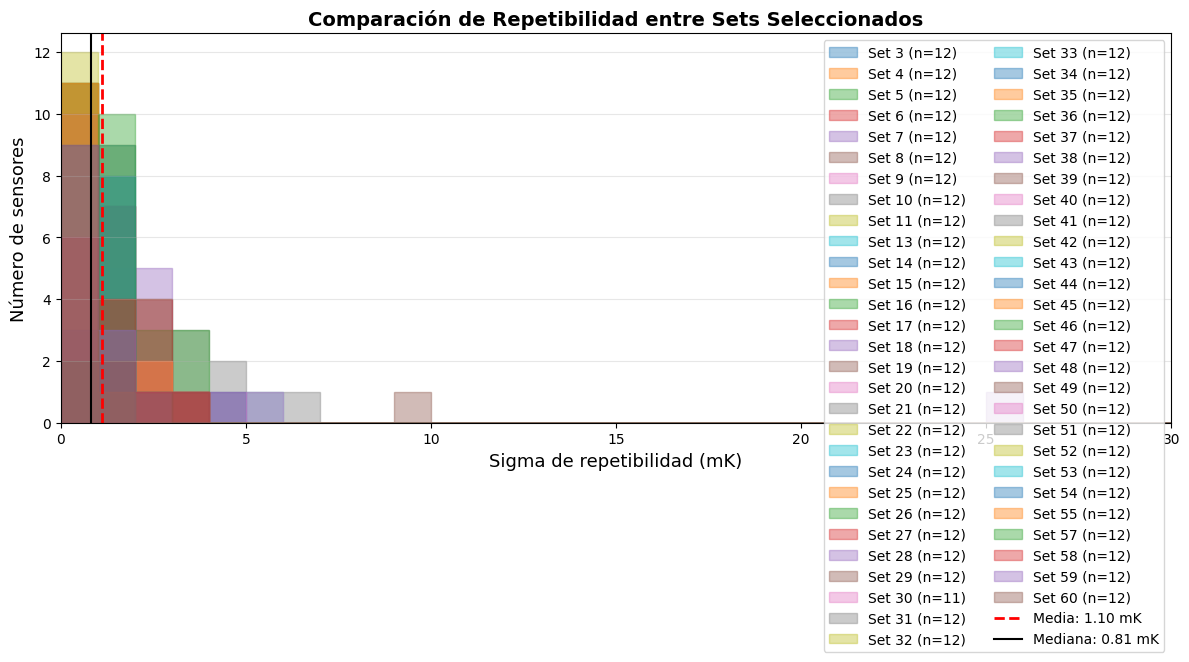


=== Resumen de Calidad por Set (Filtrado < 30mK) ===
Set 3: n=14, media=0.98 mK, mediana=0.70 mK
Set 4: n=14, media=0.92 mK, mediana=0.80 mK
Set 5: n=14, media=0.89 mK, mediana=0.80 mK
Set 6: n=14, media=0.96 mK, mediana=1.05 mK
Set 7: n=14, media=1.31 mK, mediana=0.77 mK
Set 8: n=14, media=0.75 mK, mediana=0.56 mK
Set 9: n=14, media=0.83 mK, mediana=0.83 mK
Set 10: n=14, media=3.09 mK, mediana=3.01 mK
Set 11: n=14, media=1.96 mK, mediana=1.35 mK
Set 13: n=14, media=1.78 mK, mediana=1.21 mK
Set 14: n=14, media=0.95 mK, mediana=0.97 mK
Set 15: n=14, media=1.79 mK, mediana=1.30 mK
Set 16: n=14, media=2.79 mK, mediana=2.42 mK
Set 17: n=14, media=1.68 mK, mediana=1.20 mK
Set 18: n=14, media=2.47 mK, mediana=2.22 mK
Set 19: n=14, media=1.42 mK, mediana=0.68 mK
Set 20: n=14, media=0.67 mK, mediana=0.70 mK
Set 21: n=14, media=0.80 mK, mediana=0.72 mK
Set 22: n=14, media=1.00 mK, mediana=0.95 mK
Set 23: n=14, media=1.40 mK, mediana=1.20 mK
Set 24: n=14, media=1.00 mK, mediana=0.98 mK
Set 25: 

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PREPARACIÓN DE DATOS (Manejo de tupla y mapeo único) ---
# Extraemos el diccionario si repeatability_data es una tupla
data_to_plot = repeatability_data[0] if isinstance(repeatability_data, tuple) else repeatability_data

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors # Usamos una paleta más amplia por si hay muchos sets
all_sigmas_mK = []
UMBRAL_PLOT = 30.0 # Filtro visual para que el plot no salga vacío por culpa de outliers

# Iteramos sobre los sets seleccionados
for idx, set_num in enumerate(selected_sets):
    # Convertimos a string para asegurar el match con las llaves del diccionario
    s_key = str(float(set_num)) if str(float(set_num)) in data_to_plot else set_num
    
    if s_key in data_to_plot:
        sigmas = data_to_plot[s_key]
        
        # Obtener referencias del config para este set (para excluirlas)
        s_int = int(float(set_num))
        set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(s_int, {})
        referencias = [str(s) for s in set_config.get('reference', [])]
        
        valid_sigmas_set = []
        for s_id, s_val in sigmas.items():
            if np.isfinite(s_val) and str(s_id) not in referencias:
                val_mK = s_val * 1000
                # Solo añadimos al plot si está en el rango visible
                if val_mK < UMBRAL_PLOT:
                    valid_sigmas_set.append(val_mK)
                    all_sigmas_mK.append(val_mK)
        
        if valid_sigmas_set:
            color = colors[idx % len(colors)]
            ax.hist(valid_sigmas_set, bins=np.arange(0, UMBRAL_PLOT + 1, 1.0), 
                    alpha=0.4, label=f'Set {s_int} (n={len(valid_sigmas_set)})',
                    edgecolor=color, histtype='stepfilled', color=color)

# --- 2. ESTADÍSTICAS Y FORMATO ---
if all_sigmas_mK:
    mean_global = np.mean(all_sigmas_mK)
    median_global = np.median(all_sigmas_mK)
    
    ax.axvline(mean_global, color='red', linestyle='--', linewidth=2, 
               label=f'Media: {mean_global:.2f} mK')
    ax.axvline(median_global, color='black', linestyle='-', linewidth=1.5, 
               label=f'Mediana: {median_global:.2f} mK')

    ax.set_xlabel('Sigma de repetibilidad (mK)', fontsize=13)
    ax.set_ylabel('Número de sensores', fontsize=13)
    ax.set_title('Comparación de Repetibilidad entre Sets Seleccionados', fontsize=14, fontweight='bold')
    ax.set_xlim(0, UMBRAL_PLOT)
    ax.legend(loc='upper right', fontsize=10, ncol=2 if len(selected_sets) > 5 else 1)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # --- 3. ESTADÍSTICAS COMPARATIVAS EN TEXTO ---
    print("\n=== Resumen de Calidad por Set (Filtrado < 30mK) ===")
    for set_num in selected_sets:
        s_key = str(float(set_num)) if str(float(set_num)) in data_to_plot else set_num
        if s_key in data_to_plot:
            sigmas = data_to_plot[s_key]
            # (Filtro rápido para el print)
            vals = [s*1000 for sid, s in sigmas.items() if np.isfinite(s) and abs(s*1000) < UMBRAL_PLOT]
            if vals:
                print(f"Set {int(float(set_num))}: n={len(vals)}, media={np.mean(vals):.2f} mK, mediana={np.median(vals):.2f} mK")

else:
    print("❌ Error: No se encontraron datos para graficar. Revisa los IDs de 'selected_sets'.")

### Detalle: Sigmas por Sensor

Tabla detallada mostrando las sigmas individuales de cada sensor en un set seleccionado.

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- 1. CONFIGURACIÓN ROBUSTA DEL DATA SOURCE ---
# Extraemos el diccionario si es una tupla
data_source = repeatability_data[0] if isinstance(repeatability_data, tuple) else repeatability_data

# --- 2. SELECCIÓN AUTOMÁTICA DEL SET ---
# Intentamos buscar un set que esté en selected_sets Y que tenga datos
available_keys = list(data_source.keys())

# Función para normalizar y comparar llaves
def find_matching_key(target, keys):
    targets = [str(target), str(float(target)), int(float(target))]
    for t in targets:
        if str(t) in [str(k) for k in keys]:
            # Retornamos la llave original del diccionario
            for k in keys:
                if str(k) == str(t): return k
    return None

set_to_analyze = None
if selected_sets:
    for s in selected_sets:
        match = find_matching_key(s, available_keys)
        if match:
            set_to_analyze = match
            break

# Si no encontramos ninguno de selected_sets, cogemos el primero disponible
if set_to_analyze is None and available_keys:
    set_to_analyze = available_keys[0]
    print(f"⚠️ El set solicitado no existe. Analizando el primer set disponible: {set_to_analyze}")

# --- 3. PROCESAMIENTO DE LA TABLA ---
if set_to_analyze is not None:
    sigmas = data_source[set_to_analyze]
    s_int = int(float(set_to_analyze))
    
    # Obtener info del config (referencias y descartados)
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(s_int, {})
    refs = [str(s) for s in set_config.get('reference', [])]
    discs = [str(s) for s in set_config.get('discarded', [])]
    
    rows = []
    for sensor_id, sigma in sigmas.items():
        s_id_str = str(sensor_id)
        tipo = "Normal"
        if s_id_str in refs: tipo = "REFERENCIA"
        elif s_id_str in discs: tipo = "DESCARTADO"
        
        rows.append({
            'Sensor_ID': s_id_str,
            'Sigma_mK': sigma * 1000 if (sigma is not None and np.isfinite(sigma)) else np.nan,
            'Estado': tipo
        })
    
    df_sigmas = pd.DataFrame(rows)
    df_sigmas = df_sigmas.sort_values('Sigma_mK', ascending=False).reset_index(drop=True)
    df_sigmas['Ranking'] = range(1, len(df_sigmas) + 1)
    
    # --- 4. IMPRESIÓN ---
    print(f"\n=== Tabla de Repetibilidad - Set {s_int} ===")
    print(f"Total sensores: {len(df_sigmas)} | Válidos: {df_sigmas['Sigma_mK'].notna().sum()}")
    
    cols_to_show = ['Ranking', 'Sensor_ID', 'Sigma_mK', 'Estado']
    print(f"\nTop 20 Sensores (Peor repetibilidad):")
    print(df_sigmas[cols_to_show].head(20).to_string(index=False))
    
    print(f"\nÚltimos 10 Sensores (Mejor repetibilidad):")
    print(df_sigmas[cols_to_show].tail(10).to_string(index=False))
    
    # --- 5. GUARDADO ---
    output_csv = f"set_{s_int}_repeatability_sigmas.csv"
    csv_path = Path('..') / 'docs' / output_csv
    csv_path.parent.mkdir(exist_ok=True, parents=True)
    df_sigmas.to_csv(csv_path, index=False)
    print(f"\n✓ Resultados exportados a: {csv_path}")
else:
    print("❌ No hay ningún dato de repetibilidad disponible en 'repeatability_data'.")


=== Tabla de Repetibilidad - Set 3 ===
Total sensores: 14 | Válidos: 14

Top 20 Sensores (Peor repetibilidad):
 Ranking Sensor_ID  Sigma_mK     Estado
       1     48478  4.027444 DESCARTADO
       2     48205  2.113256 DESCARTADO
       3     48202  0.960788     Normal
       4     48176  0.929275 REFERENCIA
       5     48477  0.867580     Normal
       6     48476  0.789598     Normal
       7     48063  0.770127     Normal
       8     48062  0.620272     Normal
       9     48204  0.617592     Normal
      10     48061  0.564401     Normal
      11     48060  0.463079     Normal
      12     48479  0.343827     Normal
      13     48203  0.343827     Normal
      14     48177  0.280090 REFERENCIA

Últimos 10 Sensores (Mejor repetibilidad):
 Ranking Sensor_ID  Sigma_mK     Estado
       5     48477  0.867580     Normal
       6     48476  0.789598     Normal
       7     48063  0.770127     Normal
       8     48062  0.620272     Normal
       9     48204  0.617592     Normal
    

In [22]:
# Guardar resultados en Excel y CSV
calib_set.save_results(output_file="set_calibration_results.xlsx", save_csv=True)

print(f"\nArchivos generados para {len(calib_set.calibration_constants)} sets:")
print("  - Excel: set_calibration_results.xlsx (todas las hojas)")
print("  - CSV: set_N_constants.csv y set_N_errors.csv (por cada set)")
print("\nLos sensores excluidos (referencias y descartados) aparecen como NaN en los CSV")


Guardando resultados...
✓ Excel guardado en /Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/docs/set_calibration_results.xlsx
✓ CSVs guardados en /Users/vicky/Desktop/rtd-calib-simple/RTD_Calibration/docs/ (set_N_constants.csv, set_N_errors.csv)

Archivos generados para 56 sets:
  - Excel: set_calibration_results.xlsx (todas las hojas)
  - CSV: set_N_constants.csv y set_N_errors.csv (por cada set)

Los sensores excluidos (referencias y descartados) aparecen como NaN en los CSV


## 📊 Histogramas Globales de Sigma por Ronda

Similar al notebook del proyecto bueno, genera histogramas superpuestos mostrando la distribución de sigmas por ronda.

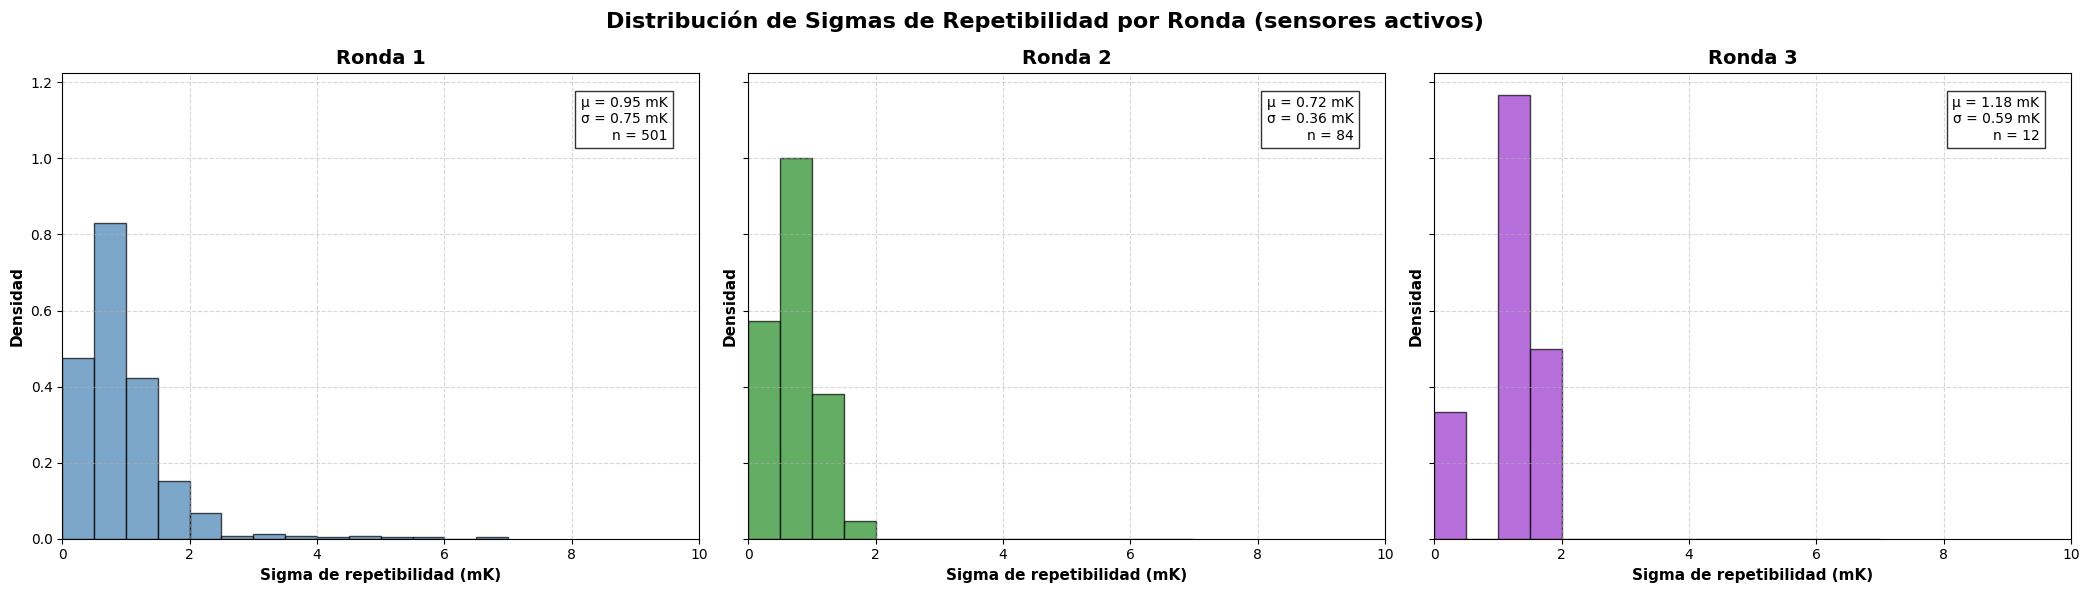

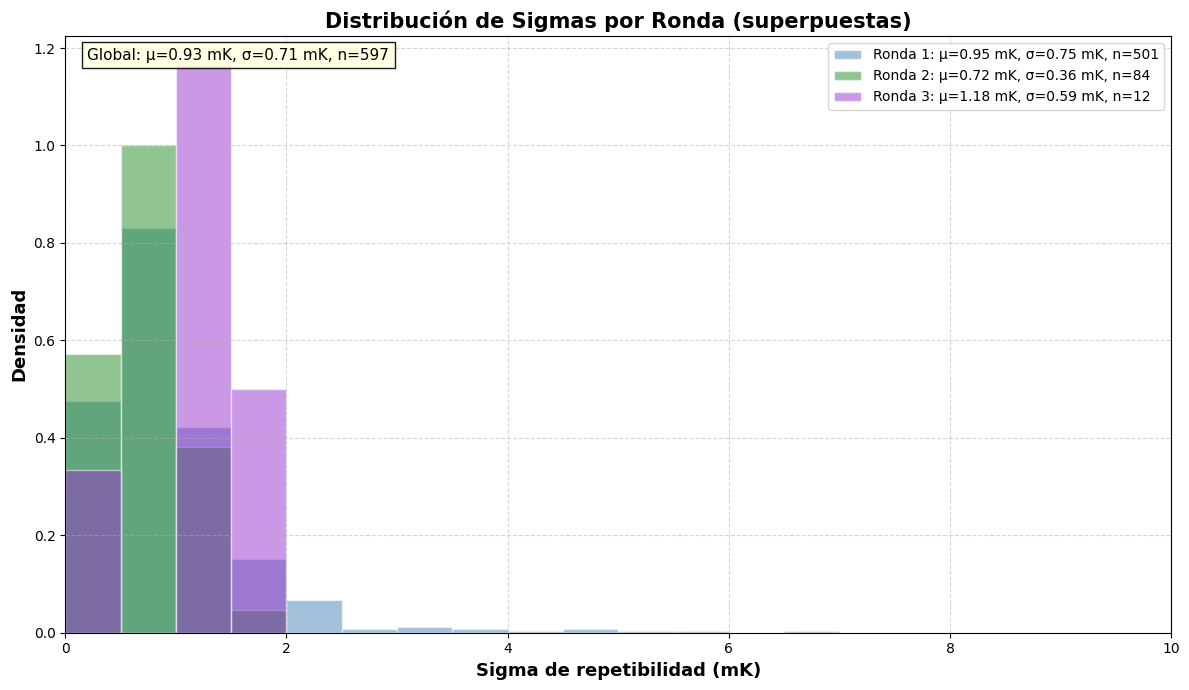


✅ Histogramas de sigma generados:
   Ronda 1: n=501, μ=0.95 mK, mediana=0.77 mK, rango=[0.06, 6.78] mK
   Ronda 2: n=84, μ=0.72 mK, mediana=0.68 mK, rango=[0.14, 1.66] mK
   Ronda 3: n=12, μ=1.18 mK, mediana=1.28 mK, rango=[0.00, 1.99] mK


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Recolectar sigmas por ronda (solo sensores activos, sin refs ni descartados)
data_to_process = repeatability_data[1] if isinstance(repeatability_data, tuple) else repeatability_data

sigmas_por_ronda = {}
for set_num in selected_sets:
    if set_num not in data_to_process:
        continue
    
    set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(set_num, {})
    ronda = set_config.get('round', None)
    if not isinstance(ronda, int):
        continue
    
    sigmas_dict = data_to_process[set_num]
    for sid, sigma in sigmas_dict.items():
        if np.isfinite(sigma):
            sigmas_por_ronda.setdefault(ronda, []).append(sigma * 1000)

# Colores por ronda
color_map = {1: 'steelblue', 2: 'forestgreen', 3: 'darkorchid', 4: 'firebrick'}

if not sigmas_por_ronda:
    print("⚠️  No hay datos para graficar")
else:
    # Calcular bins globales
    all_sigmas = [v for vals in sigmas_por_ronda.values() for v in vals]
    max_sigma = np.max(all_sigmas)
    bins = np.arange(0, min(max_sigma + 0.5, 10), 0.5)
    
    # Plot 1: Subplots separados por ronda
    rondas_ordenadas = sorted(sigmas_por_ronda.keys())
    n_rondas = len(rondas_ordenadas)
    
    if n_rondas <= 3:
        nrows, ncols = 1, n_rondas
    else:  # 4 rondas
        nrows, ncols = 2, 2
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 6*nrows), sharey=True, squeeze=False)
    axes_flat = axes.flatten()
    
    for i, ronda in enumerate(rondas_ordenadas):
        sigmas = sigmas_por_ronda[ronda]
        ax = axes_flat[i]
        
        mu = np.mean(sigmas)
        sigma_std = np.std(sigmas, ddof=1) if len(sigmas) > 1 else 0
        
        ax.hist(sigmas, bins=bins, alpha=0.7, color=color_map.get(ronda, 'gray'), density=True, edgecolor='black')
        ax.set_title(f'Ronda {ronda}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Sigma de repetibilidad (mK)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Densidad', fontsize=11, fontweight='bold')
        ax.text(0.95, 0.95, f'μ = {mu:.2f} mK\nσ = {sigma_std:.2f} mK\nn = {len(sigmas)}',
                ha='right', va='top', transform=ax.transAxes, fontsize=10,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xlim(0, 10)
    
    # Ocultar subplots sobrantes
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')
    
    plt.suptitle('Distribución de Sigmas de Repetibilidad por Ronda (sensores activos)',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Histogramas superpuestos
    fig2, ax2 = plt.subplots(figsize=(12, 7))
    
    for ronda in rondas_ordenadas:
        sigmas = sigmas_por_ronda[ronda]
        mu = np.mean(sigmas)
        sigma_std = np.std(sigmas, ddof=1) if len(sigmas) > 1 else 0
        
        ax2.hist(sigmas, bins=bins, alpha=0.5, color=color_map.get(ronda, 'gray'),
                 density=True, label=f'Ronda {ronda}: μ={mu:.2f} mK, σ={sigma_std:.2f} mK, n={len(sigmas)}',
                 edgecolor='white')
    
    # Stats globales
    mu_global = np.mean(all_sigmas)
    sigma_global = np.std(all_sigmas, ddof=1) if len(all_sigmas) > 1 else 0
    
    ax2.set_xlabel('Sigma de repetibilidad (mK)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Densidad', fontsize=13, fontweight='bold')
    ax2.set_title('Distribución de Sigmas por Ronda (superpuestas)', fontsize=15, fontweight='bold')
    ax2.legend(fontsize=10, loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.set_xlim(0, 10)
    
    ax2.text(0.02, 0.98, f'Global: μ={mu_global:.2f} mK, σ={sigma_global:.2f} mK, n={len(all_sigmas)}',
             ha='left', va='top', transform=ax2.transAxes, fontsize=11,
             bbox=dict(facecolor='lightyellow', alpha=0.9, edgecolor='black'))
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Histogramas de sigma generados:")
    for ronda in rondas_ordenadas:
        sigmas = sigmas_por_ronda[ronda]
        print(f"   Ronda {ronda}: n={len(sigmas)}, μ={np.mean(sigmas):.2f} mK, "
              f"mediana={np.median(sigmas):.2f} mK, rango=[{min(sigmas):.2f}, {max(sigmas):.2f}] mK")

## 📈 Scatter Global de Sigmas por Set

Distribución de sigmas por sensor y set, en 8 subplots. Cada punto = un sensor, coloreado por set. La línea horizontal = media del set.

📊 Límite Y: 6 mK  (puntos > 6 mK: 1/609)


/var/folders/34/d5mhvz2171lb_pxlq8p_s2480000gn/T/ipykernel_82662/2834010860.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab10').colors  # 10 colores distintos
/var/folders/34/d5mhvz2171lb_pxlq8p_s2480000gn/T/ipykernel_82662/2834010860.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab10').colors  # 10 colores distintos
/var/folders/34/d5mhvz2171lb_pxlq8p_s2480000gn/T/ipykernel_82662/2834010860.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_

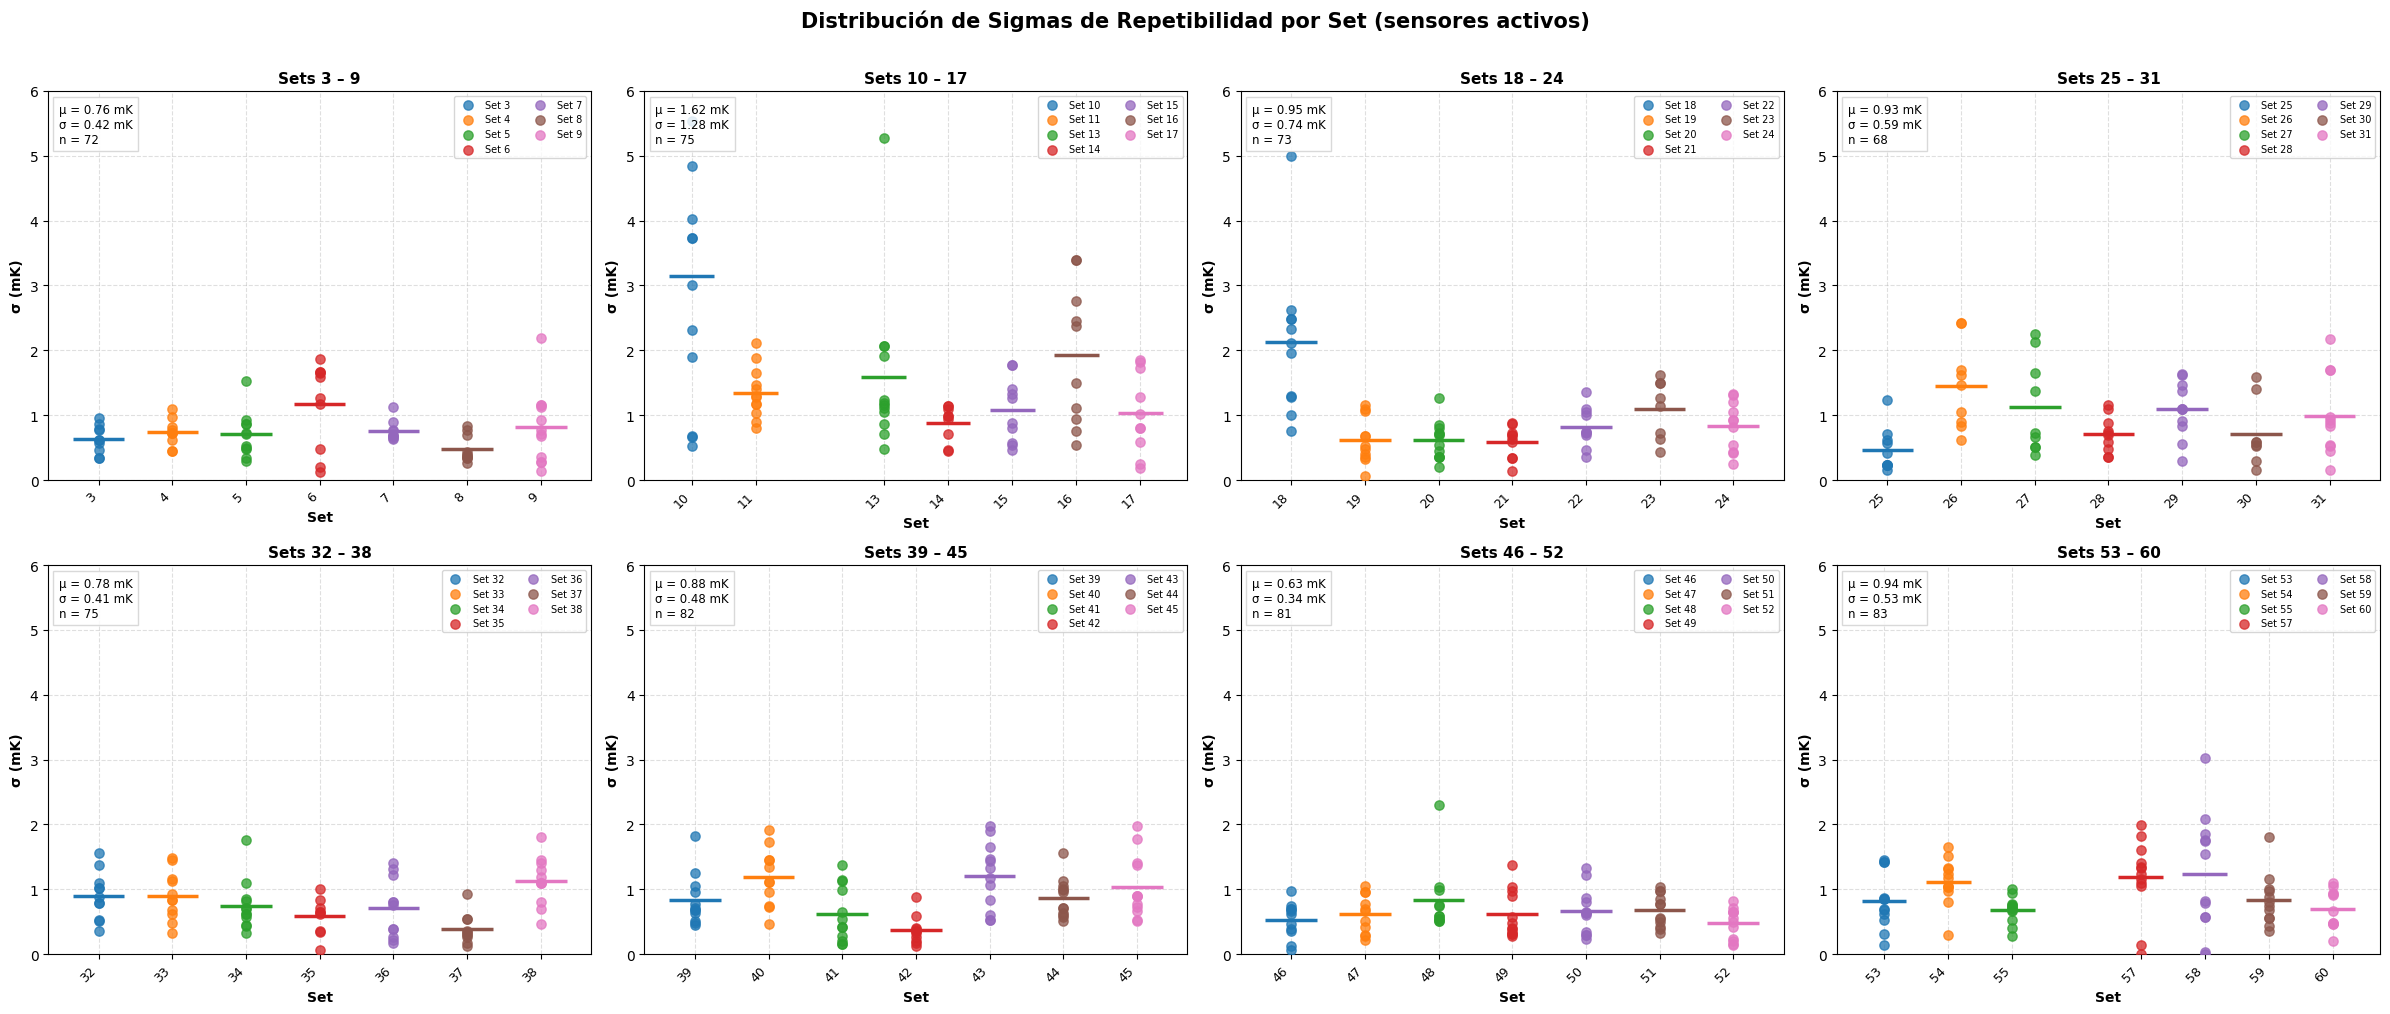


✅ Scatter de sigmas generado
   Sets procesados : 56
   Sensores totales: 609
   μ global        = 0.93 mK
   Rango           = [0.00, 6.78] mK
   σ global        = 0.71 mK


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math

# ── Parámetros ──────────────────────────────────────────────────────────────
N_SUBPLOTS   = 8       # subplots totales en la figura (layout 2×4)
ALPHA_POINTS = 0.75
S_POINTS     = 45

# ── Datos ────────────────────────────────────────────────────────────────────
data_to_process = repeatability_data[1] if isinstance(repeatability_data, tuple) else repeatability_data

# Límite Y dinámico: p98 de los datos activos, mínimo 6 mK
_flat_ylim = [v * 1000 for sd in data_to_process.values() for v in sd.values() if np.isfinite(v)]
YLIM_MAX = max(6, int(np.ceil(np.percentile(_flat_ylim, 98)))) if _flat_ylim else 6
_n_above6 = sum(1 for v in _flat_ylim if v > 6)
print(f"📊 Límite Y: {YLIM_MAX} mK  (puntos > 6 mK: {_n_above6}/{len(_flat_ylim)})")

sets_con_datos = sorted(
    [s for s in selected_sets if s in data_to_process],
    key=lambda x: float(x)
)

if not sets_con_datos:
    print("⚠️  No hay datos para graficar")
else:
    # Distribuir sets en N_SUBPLOTS grupos lo más iguales posibles
    num_sets   = len(sets_con_datos)
    chunk_size = math.ceil(num_sets / N_SUBPLOTS)
    chunks     = [sets_con_datos[i:i + chunk_size] for i in range(0, num_sets, chunk_size)]

    # ── Colores por ronda ────────────────────────────────────────────────────
    ronda_color = {1: 'steelblue', 2: 'forestgreen', 3: 'darkorchid', 4: 'firebrick'}

    def color_for_set(set_num):
        sc = calib_set.config.get('sensors', {}).get('sets', {}).get(set_num, {})
        r  = sc.get('round', None)
        return ronda_color.get(r, 'gray')

    # ── Figura 2×4 ───────────────────────────────────────────────────────────
    nrows, ncols = 2, 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes_flat = axes.flatten()

    all_sigmas_global = []

    for sp_idx, chunk in enumerate(chunks[:N_SUBPLOTS]):
        ax = axes_flat[sp_idx]

        # Un tono más oscuro/claro por set dentro del subplot (tab10 del chunk)
        palette = cm.get_cmap('tab10').colors  # 10 colores distintos

        chunk_sigmas = []

        for set_idx, set_num in enumerate(chunk):
            sigmas_dict = data_to_process[set_num]
            sigmas_mK   = [v * 1000 for v in sigmas_dict.values() if np.isfinite(v)]
            if not sigmas_mK:
                continue

            col = palette[set_idx % len(palette)]
            x_vals = [float(set_num)] * len(sigmas_mK)

            ax.scatter(x_vals, sigmas_mK,
                       color=col, alpha=ALPHA_POINTS, s=S_POINTS,
                       label=f"Set {set_num}", zorder=3)

            # Línea horizontal = media del set
            mu_set = np.mean(sigmas_mK)
            ax.hlines(mu_set, float(set_num) - 0.35, float(set_num) + 0.35,
                      colors=col, linewidth=2.5, zorder=4)

            chunk_sigmas.extend(sigmas_mK)

        all_sigmas_global.extend(chunk_sigmas)

        # Stats del grupo en el subplot
        if chunk_sigmas:
            mu_c   = np.mean(chunk_sigmas)
            std_c  = np.std(chunk_sigmas, ddof=1) if len(chunk_sigmas) > 1 else 0
            n_c    = len(chunk_sigmas)
            ax.text(0.02, 0.97,
                    f"μ = {mu_c:.2f} mK\nσ = {std_c:.2f} mK\nn = {n_c}",
                    ha='left', va='top', transform=ax.transAxes, fontsize=8.5,
                    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))

        ax.set_ylim(0, YLIM_MAX)
        ax.set_xticks([float(s) for s in chunk])
        ax.set_xticklabels([str(s) for s in chunk], rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('Set', fontsize=10, fontweight='bold')
        ax.set_ylabel('σ (mK)', fontsize=10, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.8)

        lbl = f"Sets {chunk[0]} – {chunk[-1]}" if len(chunk) > 1 else f"Set {chunk[0]}"
        ax.set_title(lbl, fontsize=11, fontweight='bold')

    # Ocultar subplots sobrantes
    for j in range(len(chunks), N_SUBPLOTS):
        axes_flat[j].axis('off')

    plt.suptitle('Distribución de Sigmas de Repetibilidad por Set (sensores activos)', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    if all_sigmas_global:
        print(f"\n✅ Scatter de sigmas generado")
        print(f"   Sets procesados : {len(sets_con_datos)}")

        print(f"   Sensores totales: {len(all_sigmas_global)}")

        print(f"   μ global        = {np.mean(all_sigmas_global):.2f} mK")        
        print(f"   Rango           = [{min(all_sigmas_global):.2f}, {max(all_sigmas_global):.2f}] mK")
        print(f"   σ global        = {np.std(all_sigmas_global, ddof=1):.2f} mK")

PLOT 1 — Solo sensores activos  (●)
📊 Límite Y: 6 mK  (puntos > 6 mK: 1/609)


/var/folders/34/d5mhvz2171lb_pxlq8p_s2480000gn/T/ipykernel_82662/1420173978.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab10').colors


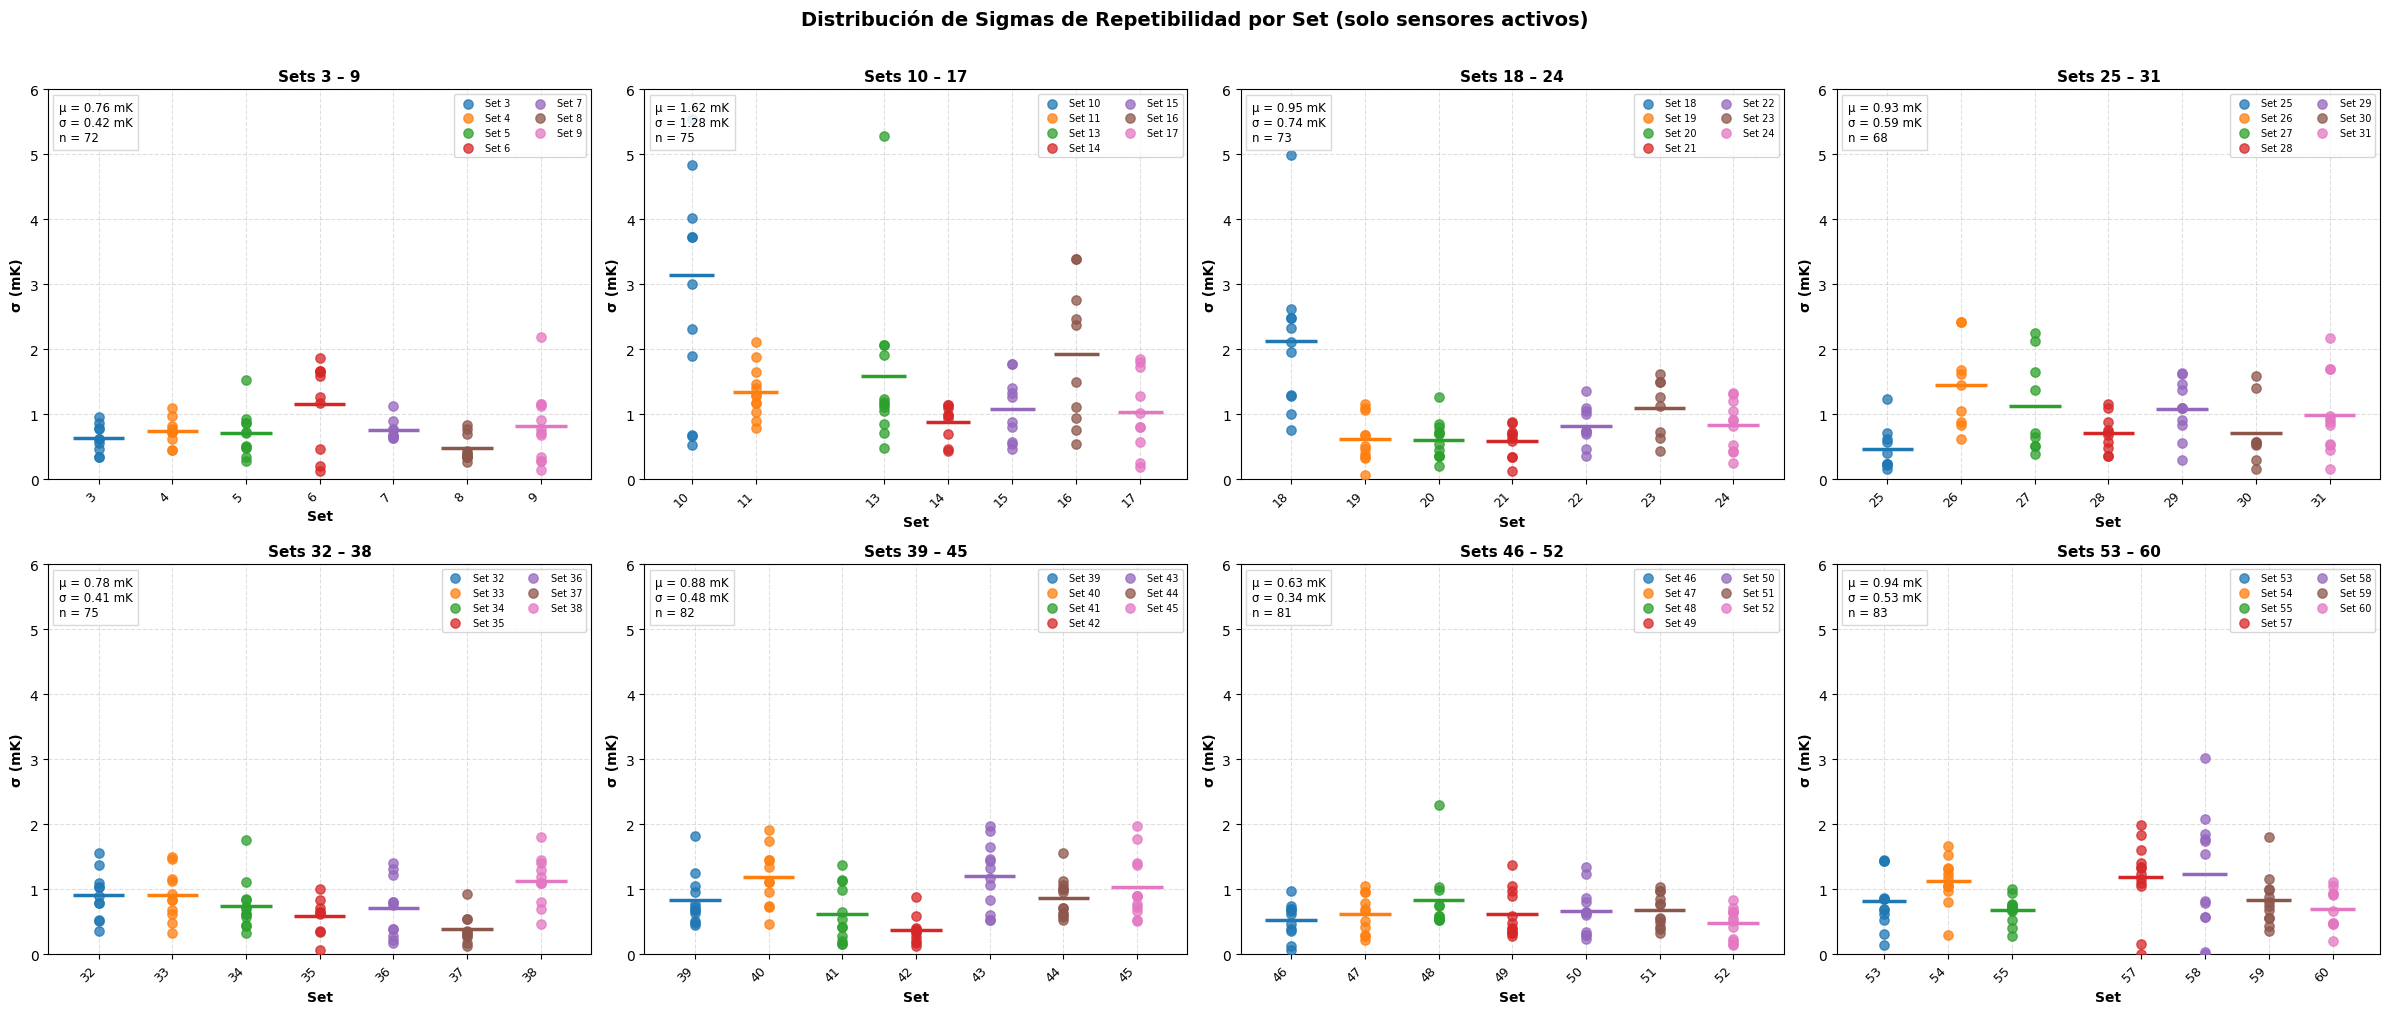

✅ Scatter sin descartados: n=609, μ=0.93 mK, σ=0.71 mK, rango=[0.00, 6.78] mK
📊 Límite Y: 6 mK  (puntos > 6 mK: 9/783)


/var/folders/34/d5mhvz2171lb_pxlq8p_s2480000gn/T/ipykernel_82662/1420173978.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab10').colors


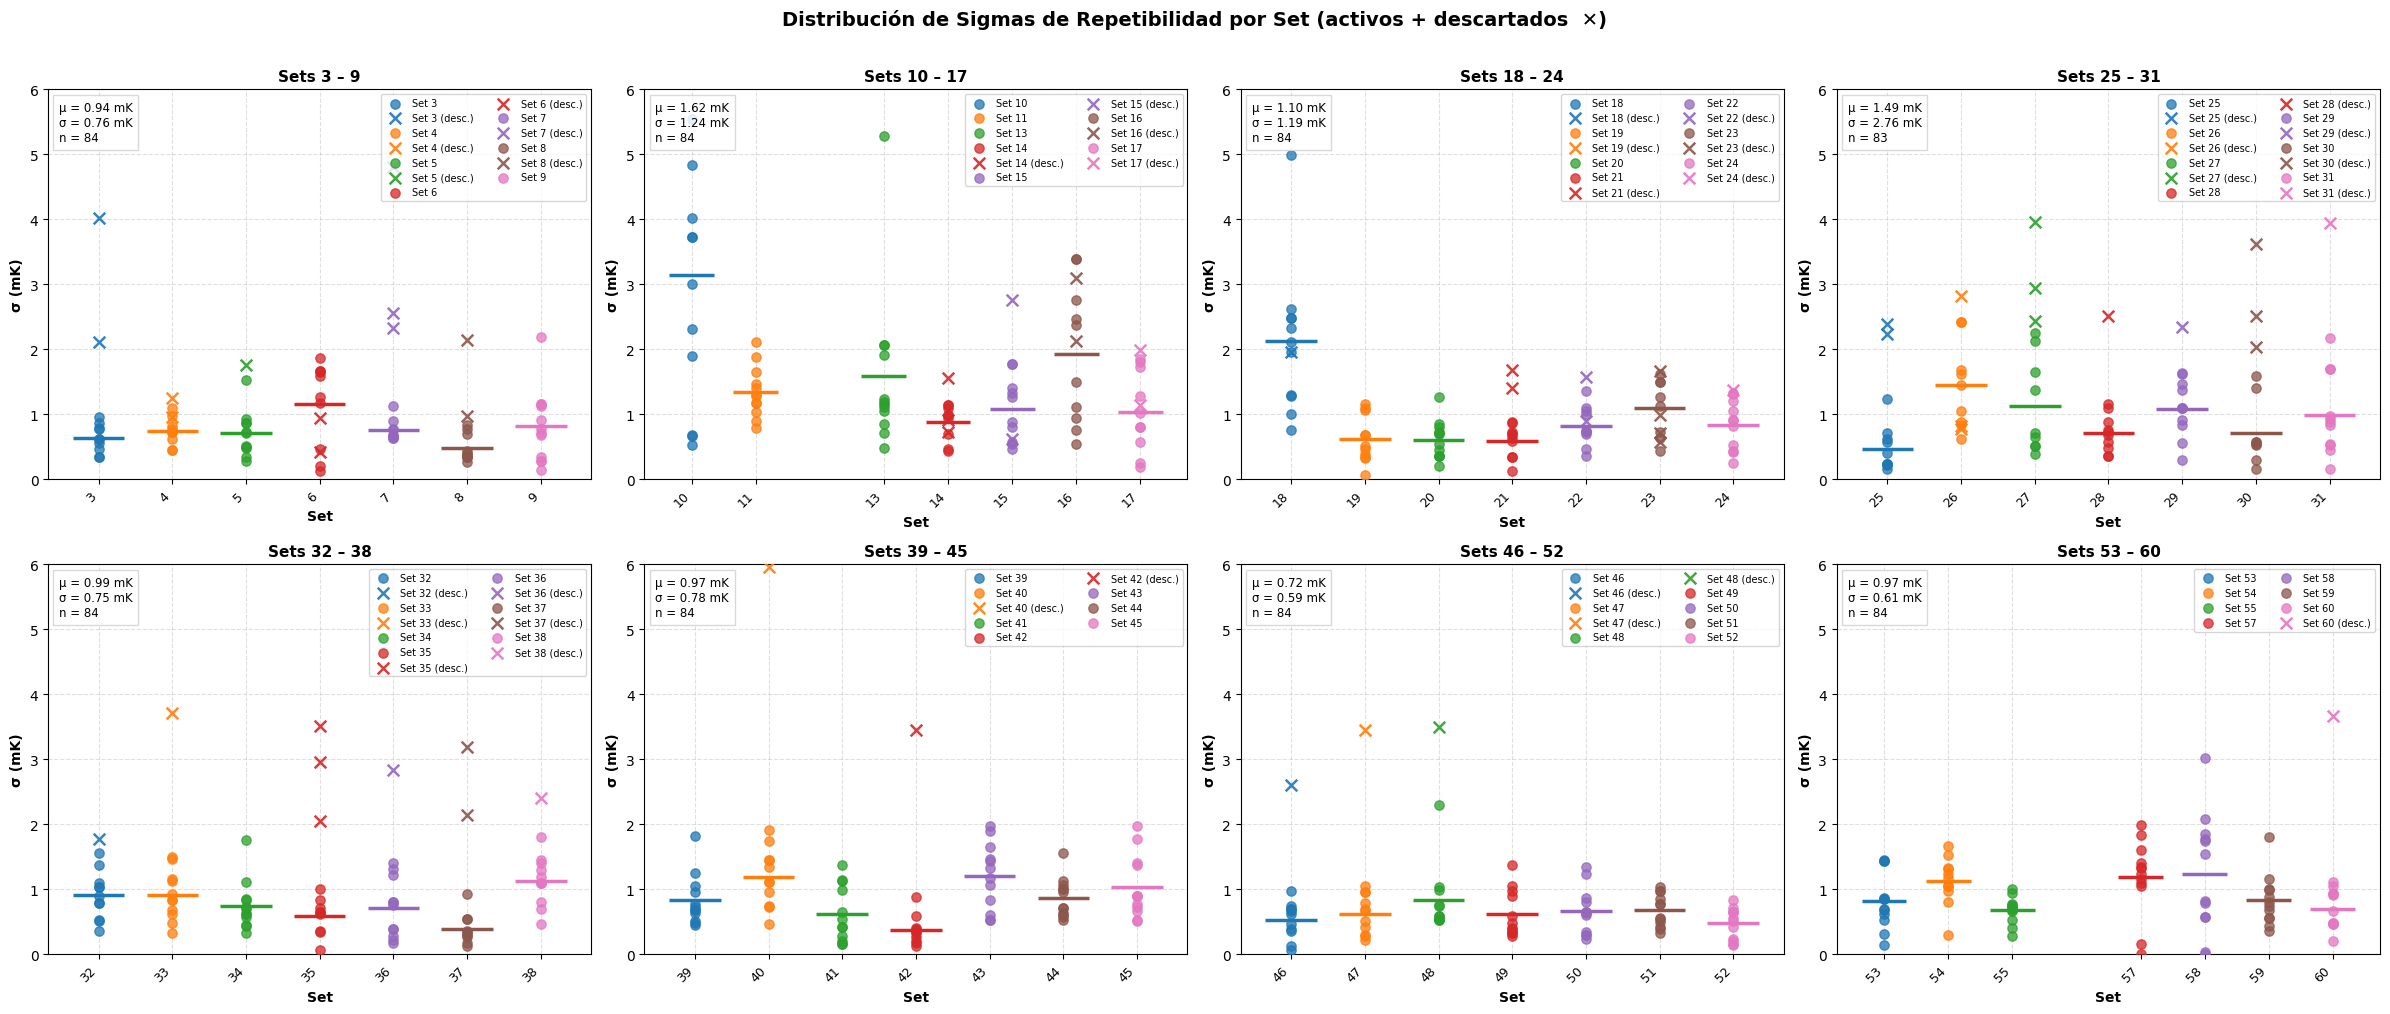

✅ Scatter con descartados: n=671, μ=1.10 mK, σ=1.30 mK, rango=[0.00, 25.02] mK

PLOT 2 — Activos (●)  +  Descartados (✕)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math

# ── Función reutilizable para el scatter de sigmas ───────────────────────────
def _scatter_sigmas_8subplots(data_active, data_all, include_discarded: bool,
                               n_subplots=8, ylim_max=None):
    """
    data_active : dict  {set_num: {sensor_id: sigma}} — sin refs ni descartados
    data_all    : dict  {set_num: {sensor_id: sigma}} — todos (refs + descartados)
    include_discarded : si True dibuja descartados con ✕, si False solo activos
    """
    palette = cm.get_cmap('tab10').colors

    sets_con_datos = sorted(
        [s for s in selected_sets if s in data_active],
        key=lambda x: float(x)
    )
    if not sets_con_datos:
        print("⚠️  No hay datos para graficar")
        return

    # Límite Y dinámico:
    #   - Con descartados → max * 1.1  (mostrar todos los puntos sin corte)
    #   - Solo activos    → p98        (evitar que 1-2 outliers activos estiren el eje)
    if ylim_max is None:
        src = data_all if include_discarded else data_active
        _flat = [v * 1000 for sd in src.values() for v in sd.values() if np.isfinite(v)]
        if _flat:
            if include_discarded:
                ylim_max = max(6, int(np.ceil(max(_flat) * 1.1)))
            else:
                ylim_max = max(6, int(np.ceil(np.percentile(_flat, 98))))
        else:
            ylim_max = 6
        _n_above6 = sum(1 for v in _flat if v > 6)
        print(f"📊 Límite Y: {ylim_max} mK  (puntos > 6 mK: {_n_above6}/{len(_flat)})")

    chunk_size = math.ceil(len(sets_con_datos) / n_subplots)
    chunks = [sets_con_datos[i:i + chunk_size]
              for i in range(0, len(sets_con_datos), chunk_size)]

    nrows, ncols = 2, 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes_flat = axes.flatten()

    all_sigmas_fig = []

    for sp_idx, chunk in enumerate(chunks[:n_subplots]):
        ax = axes_flat[sp_idx]
        chunk_sigmas = []

        for set_idx, set_num in enumerate(chunk):
            col = palette[set_idx % len(palette)]

            # ── Sensores activos (círculos) ──────────────────────────────
            active_dict  = data_active.get(set_num, {})
            active_sigmas = [v * 1000 for v in active_dict.values() if np.isfinite(v)]
            if active_sigmas:
                ax.scatter([float(set_num)] * len(active_sigmas), active_sigmas,
                           color=col, marker='o', alpha=0.75, s=45,
                           label=f"Set {set_num}", zorder=3)
                mu_set = np.mean(active_sigmas)
                ax.hlines(mu_set,
                          float(set_num) - 0.35, float(set_num) + 0.35,
                          colors=col, linewidth=2.5, zorder=4)
                chunk_sigmas.extend(active_sigmas)

            # ── Sensores descartados (✕) ─────────────────────────────────
            if include_discarded:
                set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(set_num, {})
                refs_set   = {str(r) for r in set_config.get('reference', [])}
                disc_set   = {str(r) for r in set_config.get('discarded', [])}

                all_dict = data_all.get(set_num, {})
                disc_sigmas = [
                    v * 1000 for sid, v in all_dict.items()
                    if str(sid) in disc_set and str(sid) not in refs_set
                    and np.isfinite(v)
                ]
                if disc_sigmas:
                    ax.scatter([float(set_num)] * len(disc_sigmas), disc_sigmas,
                               color=col, marker='x', alpha=0.9, s=70,
                               linewidths=1.8, zorder=5,
                               label=f"Set {set_num} (desc.)")
                    chunk_sigmas.extend(disc_sigmas)

        all_sigmas_fig.extend(chunk_sigmas)

        if chunk_sigmas:
            mu_c  = np.mean(chunk_sigmas)
            std_c = np.std(chunk_sigmas, ddof=1) if len(chunk_sigmas) > 1 else 0
            ax.text(0.02, 0.97,
                    f"μ = {mu_c:.2f} mK\nσ = {std_c:.2f} mK\nn = {len(chunk_sigmas)}",
                    ha='left', va='top', transform=ax.transAxes, fontsize=8.5,
                    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))

        ax.set_ylim(0, ylim_max)
        ax.axhline(6, color='gray', linestyle=':', linewidth=1, alpha=0.6)
        ax.set_xticks([float(s) for s in chunk])
        ax.set_xticklabels([str(s) for s in chunk], rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('Set', fontsize=10, fontweight='bold')
        ax.set_ylabel('σ (mK)', fontsize=10, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.8)
        lbl = f"Sets {chunk[0]} – {chunk[-1]}" if len(chunk) > 1 else f"Set {chunk[0]}"
        ax.set_title(lbl, fontsize=11, fontweight='bold')

    for j in range(len(chunks), n_subplots):
        axes_flat[j].axis('off')

    suffix = " (activos + descartados  ✕)" if include_discarded else " (solo sensores activos)"
    plt.suptitle(f'Distribución de Sigmas de Repetibilidad por Set{suffix}',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    if all_sigmas_fig:
        tag = "con descartados" if include_discarded else "sin descartados"
        print(f"✅ Scatter {tag}: n={len(all_sigmas_fig)}, "
              f"μ={np.mean(all_sigmas_fig):.2f} mK, "
              f"σ={np.std(all_sigmas_fig, ddof=1):.2f} mK, "
              f"rango=[{min(all_sigmas_fig):.2f}, {max(all_sigmas_fig):.2f}] mK")


# ── Obtener ambas versiones de los datos ─────────────────────────────────────
data_all_sensors      = repeatability_data[0]  # todos: refs + descartados + activos
data_active_only      = repeatability_data[1]  # solo activos (sin refs ni descartados)

print("=" * 60)
print("PLOT 1 — Solo sensores activos  (●)")
print("=" * 60)
_scatter_sigmas_8subplots(data_active_only, data_all_sensors, include_discarded=False)

print()
print("=" * 60)
print("PLOT 2 — Activos (●)  +  Descartados (✕)")
print("=" * 60)
_scatter_sigmas_8subplots(data_active_only, data_all_sensors, include_discarded=True)


📊 Límite Y: 6 mK  (puntos > 6 mK: 9/783)


/var/folders/34/d5mhvz2171lb_pxlq8p_s2480000gn/T/ipykernel_82662/3470022127.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab10').colors


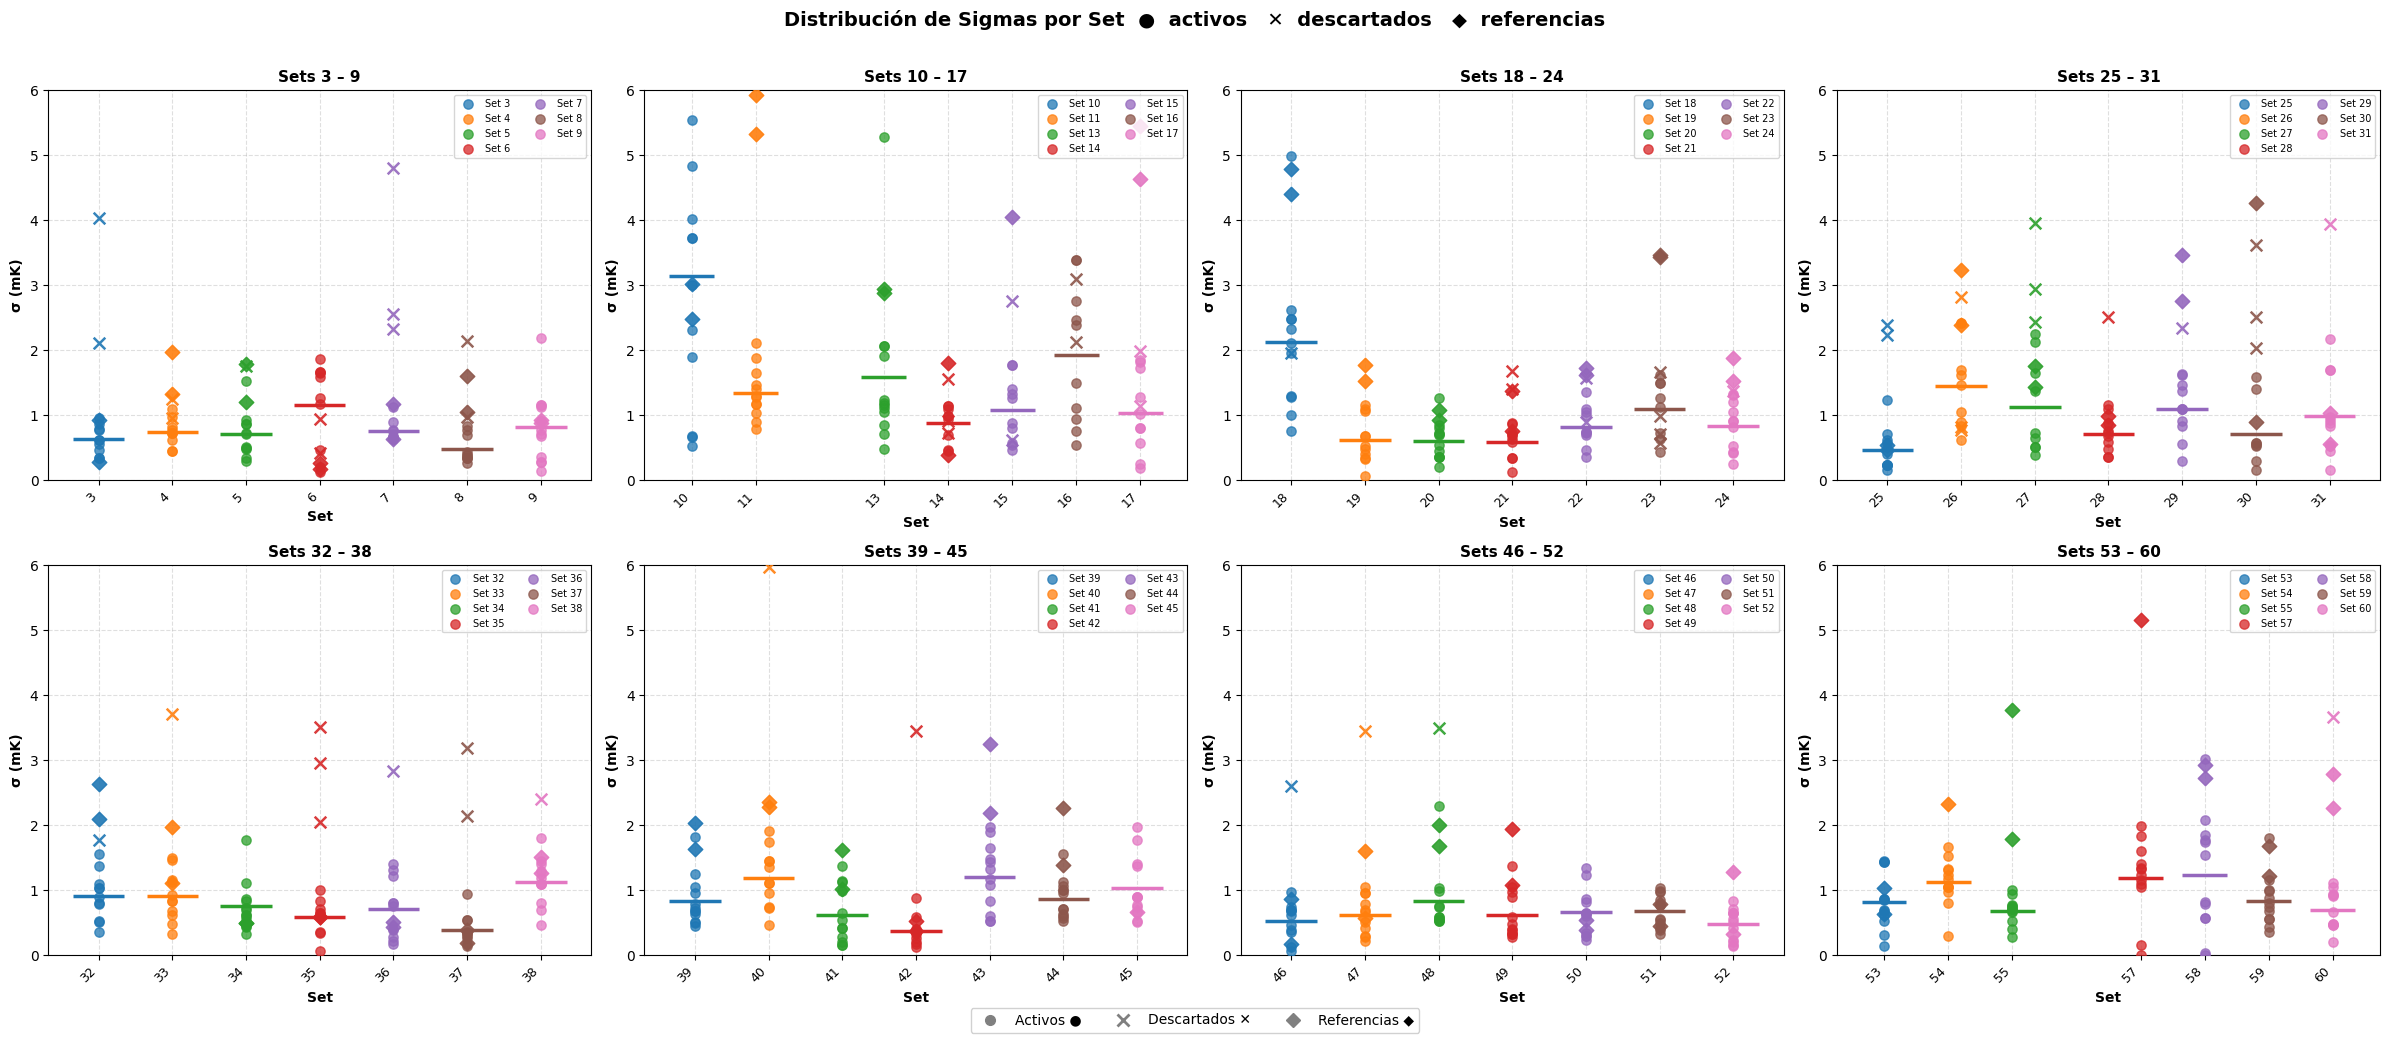

✅ Scatter completo: n=783, μ=1.25 mK, σ=1.53 mK


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math

# ── PLOT 3: Activos (●) + Descartados (✕) + Referencias (◆) ─────────────────
palette = cm.get_cmap('tab10').colors

sets_con_datos = sorted(
    [s for s in selected_sets if s in data_active_only],
    key=lambda x: float(x)
)

n_subplots = 8
chunk_size = math.ceil(len(sets_con_datos) / n_subplots)
chunks = [sets_con_datos[i:i + chunk_size] for i in range(0, len(sets_con_datos), chunk_size)]

nrows, ncols = 2, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes_flat = axes.flatten()

# Límite Y: max * 1.1 para mostrar todos los descartados sin corte, mínimo 6 mK
_flat_p3 = [v * 1000 for sd in data_all_sensors.values() for v in sd.values() if np.isfinite(v)]
ylim_dyn = max(6, int(np.ceil(max(_flat_p3) * 1.1))) if _flat_p3 else 6
_n_above6_p3 = sum(1 for v in _flat_p3 if v > 6)
print(f"📊 Límite Y: {ylim_dyn} mK  (puntos > 6 mK: {_n_above6_p3}/{len(_flat_p3)})")

all_sigmas_fig = []

for sp_idx, chunk in enumerate(chunks[:n_subplots]):
    ax = axes_flat[sp_idx]
    chunk_sigmas = []

    for set_idx, set_num in enumerate(chunk):
        col = palette[set_idx % len(palette)]
        x = float(set_num)

        set_config = calib_set.config.get('sensors', {}).get('sets', {}).get(set_num, {})
        refs_set   = {str(r) for r in set_config.get('reference', [])}
        disc_set   = {str(r) for r in set_config.get('discarded', [])}

        all_dict = data_all_sensors.get(set_num, {})

        # ● Activos
        active_sigmas = [v * 1000 for sid, v in all_dict.items()
                         if str(sid) not in refs_set and str(sid) not in disc_set
                         and np.isfinite(v)]
        if active_sigmas:
            ax.scatter([x] * len(active_sigmas), active_sigmas,
                       color=col, marker='o', alpha=0.75, s=45,
                       label=f"Set {set_num}", zorder=3)
            ax.hlines(np.mean(active_sigmas), x - 0.35, x + 0.35,
                      colors=col, linewidth=2.5, zorder=4)
            chunk_sigmas.extend(active_sigmas)

        # ✕ Descartados
        disc_sigmas = [v * 1000 for sid, v in all_dict.items()
                       if str(sid) in disc_set and str(sid) not in refs_set
                       and np.isfinite(v)]
        if disc_sigmas:
            ax.scatter([x] * len(disc_sigmas), disc_sigmas,
                       color=col, marker='x', alpha=0.9, s=70, linewidths=1.8,
                       zorder=5)
            chunk_sigmas.extend(disc_sigmas)

        # ◆ Referencias
        ref_sigmas = [v * 1000 for sid, v in all_dict.items()
                      if str(sid) in refs_set and np.isfinite(v)]
        if ref_sigmas:
            ax.scatter([x] * len(ref_sigmas), ref_sigmas,
                       color=col, marker='D', alpha=0.9, s=55, zorder=5)
            chunk_sigmas.extend(ref_sigmas)

    all_sigmas_fig.extend(chunk_sigmas)

    if chunk_sigmas:
        mu_c = np.mean(chunk_sigmas)
    ax.set_ylim(0, ylim_dyn)
    ax.axhline(6, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.set_xticks([float(s) for s in chunk])
    ax.set_xticklabels([str(s) for s in chunk], rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Set', fontsize=10, fontweight='bold')
    ax.set_ylabel('σ (mK)', fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=7, loc='upper right', ncol=2, framealpha=0.8)
    lbl = f"Sets {chunk[0]} – {chunk[-1]}" if len(chunk) > 1 else f"Set {chunk[0]}"
    ax.set_title(lbl, fontsize=11, fontweight='bold')

for j in range(len(chunks), n_subplots):
    axes_flat[j].axis('off')

# Leyenda global de marcadores
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='gray', linestyle='None', markersize=7, label='Activos ●'),
    Line2D([0], [0], marker='x', color='gray', linestyle='None', markersize=8, markeredgewidth=2, label='Descartados ✕'),
    Line2D([0], [0], marker='D', color='gray', linestyle='None', markersize=7, label='Referencias ◆'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Distribución de Sigmas por Set  ●  activos   ✕  descartados   ◆  referencias',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

if all_sigmas_fig:
    print(f"✅ Scatter completo: n={len(all_sigmas_fig)}, "
          f"μ={np.mean(all_sigmas_fig):.2f} mK, "
          f"σ={np.std(all_sigmas_fig, ddof=1):.2f} mK")


📊 Límite Y: 6 mK  (puntos > 6 mK: 1/527)


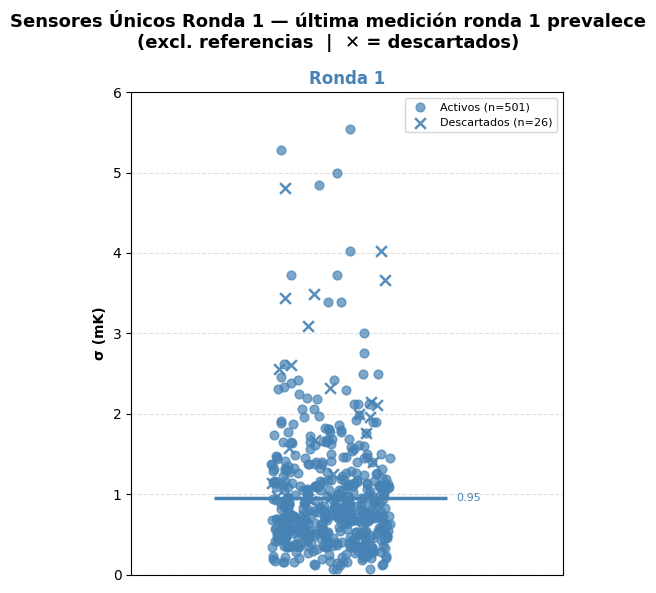

✅ 527 sensores únicos ronda 1  (501 activos + 26 descartados)
   Ronda 1: 501 activos, 26 descartados  → total 527


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ── Scatter de sensores únicos ronda 1 (última medición ronda 1 prevalece) ───
# Solo se procesan sets de ronda 1. Si un sensor fue re-medido en ronda 2/3,
# se usa su último valor de ronda 1 (el set ronda 1 con número más alto).
# Descartados SÍ se incluyen (marcados con ✕), referencias NO.

_palette_r = {1: 'steelblue', 2: 'forestgreen', 3: 'darkorchid', 4: 'firebrick'}

data_src = repeatability_data[0]
unique_map_scatter = {}   # {sensor_id_str: (sigma_mK, ronda, is_discarded)}

sorted_set_names = sorted(data_src.keys(), key=lambda x: int(float(x)))

for set_num in sorted_set_names:
    s_key = int(float(set_num))
    set_config  = calib_set.config.get('sensors', {}).get('sets', {}).get(s_key, {})
    ronda       = set_config.get('round', None)
    if not isinstance(ronda, int):
        continue
    if ronda != 1:          # solo ronda 1 → última medición ronda 1 prevalece
        continue
    refs_set = {str(r) for r in set_config.get('reference', [])}
    disc_set = {str(r) for r in set_config.get('discarded', [])}

    for s_id, s_val in data_src[set_num].items():
        if not np.isfinite(s_val) or str(s_id) in refs_set:
            continue
        is_disc = str(s_id) in disc_set
        unique_map_scatter[str(s_id)] = (s_val * 1000, ronda, is_disc)

# Agrupar (solo habrá ronda 1)
by_round = {}
for sid, (val, ronda, is_disc) in unique_map_scatter.items():
    entry = by_round.setdefault(ronda, {'active': [], 'disc': []})
    if is_disc:
        entry['disc'].append(val)
    else:
        entry['active'].append(val)

rondas = sorted(by_round.keys())
n_rondas = len(rondas)

# Límite Y: max * 1.1 para que todos los descartados sean visibles, mínimo 6 mK
_flat_p45 = [v for d in by_round.values() for v in d['active'] + d['disc']]
ylim_dyn = max(6, int(np.ceil(max(_flat_p45) * 1.1))) if _flat_p45 else 6
_n_above6_p45 = sum(1 for v in _flat_p45 if v > 6)
print(f"📊 Límite Y: {ylim_dyn} mK  (puntos > 6 mK: {_n_above6_p45}/{len(_flat_p45)})")

fig, axes = plt.subplots(1, n_rondas, figsize=(5 * n_rondas, 6), sharey=True)
if n_rondas == 1:
    axes = [axes]

for ax, ronda in zip(axes, rondas):
    col    = _palette_r.get(ronda, 'gray')
    active = by_round[ronda]['active']
    disc   = by_round[ronda]['disc']

    rng = np.random.default_rng(42)

    # ● Activos
    if active:
        jitter = rng.uniform(-0.18, 0.18, len(active))
        ax.scatter(jitter, active, color=col, marker='o', alpha=0.7, s=40,
                   label=f'Activos (n={len(active)})', zorder=3)
        mu = np.mean(active)
        ax.hlines(mu, -0.35, 0.35, colors=col, linewidth=2.5, zorder=4)
        ax.text(0.38, mu, f'{mu:.2f}', va='center', fontsize=8, color=col)

    # ✕ Descartados
    if disc:
        jitter_d = rng.uniform(-0.18, 0.18, len(disc))
        ax.scatter(jitter_d, disc, color=col, marker='x', alpha=0.9, s=60,
                   linewidths=1.8, zorder=5,
                   label=f'Descartados (n={len(disc)})')

    all_vals = active + disc
    if all_vals:
        mu_c = np.mean(all_vals)
    ax.set_ylim(0, ylim_dyn)
    ax.axhline(6, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.set_xlim(-0.6, 0.7)
    ax.set_xticks([])
    ax.set_title(f'Ronda {ronda}', fontsize=12, fontweight='bold', color=col)
    ax.set_ylabel('σ (mK)', fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Sensores Únicos Ronda 1 — última medición ronda 1 prevalece\n'
             '(excl. referencias  |  ✕ = descartados)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

total = len(unique_map_scatter)
n_disc = sum(1 for _, _, d in unique_map_scatter.values() if d)
print(f"✅ {total} sensores únicos ronda 1  ({total - n_disc} activos + {n_disc} descartados)")
for r in rondas:
    na = len(by_round[r]['active'])
    nd = len(by_round[r]['disc'])
    print(f"   Ronda {r}: {na} activos, {nd} descartados  → total {na+nd}")


In [28]:
# ── DIAGNÓSTICO: gap entre histograma (n=501) y scatter (n=444) ──────────────
import numpy as np

data_all = repeatability_data[0]
sets_cfg = calib_set.config.get('sensors', {}).get('sets', {})
UMBRAL = 30.0

# ─ Reconstruir unique_map del histograma (cell 16): excluye refs, incluye disc ─
unique_hist = {}
for set_num in sorted(data_all.keys(), key=lambda x: int(float(x))):
    s_key = int(float(set_num))
    sc = sets_cfg.get(s_key, {})
    ronda = sc.get('round', None)
    if not isinstance(ronda, int):
        continue
    refs = {str(s) for s in sc.get('reference', [])}
    for s_id, s_val in data_all[set_num].items():
        if not np.isfinite(s_val) or str(s_id) in refs:
            continue
        unique_hist[str(s_id)] = (s_val * 1000, ronda)

# ─ Reconstruir unique_map del scatter (cell 45): excluye refs, marca disc ─────
unique_scat = {}
for set_num in sorted(data_all.keys(), key=lambda x: int(float(x))):
    s_key = int(float(set_num))
    sc = sets_cfg.get(s_key, {})
    ronda = sc.get('round', None)
    if not isinstance(ronda, int):
        continue
    refs_set = {str(r) for r in sc.get('reference', [])}
    disc_set = {str(r) for r in sc.get('discarded', [])}
    for s_id, s_val in data_all[set_num].items():
        if not np.isfinite(s_val) or str(s_id) in refs_set:
            continue
        is_disc = str(s_id) in disc_set
        unique_scat[str(s_id)] = (s_val * 1000, ronda, is_disc)

# ─ Comparar ronda 1 ───────────────────────────────────────────────────────────
hist_r1_in  = {sid for sid, (v, r) in unique_hist.items() if r == 1 and v <= UMBRAL}
hist_r1_all = {sid for sid, (v, r) in unique_hist.items() if r == 1}
scat_r1     = {sid for sid, (v, r, d) in unique_scat.items() if r == 1}
scat_r1_act = {sid for sid, (v, r, d) in unique_scat.items() if r == 1 and not d}
scat_r1_dis = {sid for sid, (v, r, d) in unique_scat.items() if r == 1 and d}

print(f"Histograma ronda1  (n legend, ≤{UMBRAL}mK) : {len(hist_r1_in)}")
print(f"Histograma ronda1  (total incl. outliers)  : {len(hist_r1_all)}")
print(f"Scatter   ronda1   (total)                 : {len(scat_r1)} = {len(scat_r1_act)} activos + {len(scat_r1_dis)} descartados")
print()

only_hist = hist_r1_all - scat_r1
only_scat = scat_r1 - hist_r1_all
print(f"Solo en histograma (no en scatter): {len(only_hist)}")
print(f"Solo en scatter (no en histograma): {len(only_scat)}")

# ─ Detallar sensores que están en histograma pero no en scatter ────────────────
def sensor_history(sid):
    hist = []
    for sn in sorted(data_all.keys(), key=lambda x: int(float(x))):
        sk = int(float(sn))
        sc2 = sets_cfg.get(sk, {})
        if str(sid) not in [str(x) for x in data_all[sn].keys()]:
            continue
        refs_sn = {str(x) for x in sc2.get('reference', [])}
        disc_sn = {str(x) for x in sc2.get('discarded', [])}
        rd2 = sc2.get('round', '?')
        tag = 'REF' if str(sid) in refs_sn else ('DISC' if str(sid) in disc_sn else 'active')
        hist.append(f"{sk}[r{rd2},{tag}]")
    return hist

if only_hist:
    print(f"\nSensores en histograma pero NO en scatter — primeros 30:")
    for sid in sorted(only_hist)[:30]:
        v, r = unique_hist[sid]
        print(f"  {sid}: {v:.2f}mK ronda={r}  →  {sensor_history(sid)}")

if only_scat:
    print(f"\nSensores en scatter pero NO en histograma — primeros 30:")
    for sid in sorted(only_scat)[:30]:
        v, r, d = unique_scat[sid]
        print(f"  {sid}: {v:.2f}mK ronda={r} disc={d}  →  {sensor_history(sid)}")

# ─ Sensores con ronda diferente entre ambos ───────────────────────────────────
diff_round = {sid: (unique_hist[sid][1], unique_scat[sid][1])
              for sid in set(unique_hist) & set(unique_scat)
              if unique_hist[sid][1] != unique_scat[sid][1]}
print(f"\nSensores con ronda distinta entre hist y scatter: {len(diff_round)}")
for sid, (rh, rs) in list(diff_round.items())[:20]:
    print(f"  {sid}: hist=ronda{rh}  scat=ronda{rs}  →  {sensor_history(sid)}")


Histograma ronda1  (n legend, ≤30.0mK) : 444
Histograma ronda1  (total incl. outliers)  : 444
Scatter   ronda1   (total)                 : 444 = 418 activos + 26 descartados

Solo en histograma (no en scatter): 0
Solo en scatter (no en histograma): 0

Sensores con ronda distinta entre hist y scatter: 0
